
# Round 3 Analysis

Initial notebook setup for Round 3:
- robust data loading for underlyings and vouchers
- reusable helpers for plotting and option-specific calculations
- first broad-pass diagnostics for `HYDROGEL_PACK`, `VELVETFRUIT_EXTRACT`, and the `VEV_*` voucher family

This pass is descriptive. The goal is to understand the structure of the products before testing specific signals.


In [1]:

import math
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

%matplotlib inline

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.25
pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 140)


In [2]:

DATA_DIR = Path('../backtester/prosperity3bt/resources/round3')
PRICE_FILES = {day: DATA_DIR / f'prices_round_3_day_{day}.csv' for day in [0, 1, 2]}
TRADE_FILES = {day: DATA_DIR / f'trades_round_3_day_{day}.csv' for day in [0, 1, 2]}

DAY_OFFSET = 1_000_000
UNDERLYINGS = ['HYDROGEL_PACK', 'VELVETFRUIT_EXTRACT']
VOUCHERS = ['VEV_4000', 'VEV_4500', 'VEV_5000', 'VEV_5100', 'VEV_5200', 'VEV_5300', 'VEV_5400', 'VEV_5500', 'VEV_6000', 'VEV_6500']
ALL_PRODUCTS = UNDERLYINGS + VOUCHERS

# Historical TTE mapping implied by the round instructions.
# Historical day 0 aligns with TTE=8, day 1 with TTE=7, day 2 with TTE=6.
TTE_BY_DAY = {0: 8, 1: 7, 2: 6}


def load_prices(price_files: dict[int, Path]) -> pd.DataFrame:
    frames = []
    for day, path in price_files.items():
        df = pd.read_csv(path, sep=';')
        df['day'] = day
        df['global_timestamp'] = df['timestamp'] + day * DAY_OFFSET
        frames.append(df)
    prices = pd.concat(frames, ignore_index=True).sort_values(['global_timestamp', 'product']).reset_index(drop=True)
    return prices


def load_trades(trade_files: dict[int, Path]) -> pd.DataFrame:
    frames = []
    for day, path in trade_files.items():
        df = pd.read_csv(path, sep=';')
        df['day'] = day
        df['global_timestamp'] = df['timestamp'] + day * DAY_OFFSET
        frames.append(df)
    trades = pd.concat(frames, ignore_index=True).sort_values(['global_timestamp', 'symbol']).reset_index(drop=True)
    return trades


def strike_from_symbol(symbol: str) -> float | None:
    if not symbol.startswith('VEV_'):
        return None
    return float(symbol.split('_')[1])


def norm_cdf(x: float) -> float:
    return 0.5 * (1.0 + math.erf(x / math.sqrt(2.0)))


def black_scholes_call_price(spot: float, strike: float, tte_days: float, sigma: float, r: float = 0.0) -> float:
    t = max(tte_days, 1e-9) / 365.0
    if spot <= 0 or strike <= 0 or sigma <= 0 or t <= 0:
        return max(spot - strike, 0.0)
    d1 = (math.log(spot / strike) + (r + 0.5 * sigma * sigma) * t) / (sigma * math.sqrt(t))
    d2 = d1 - sigma * math.sqrt(t)
    return spot * norm_cdf(d1) - strike * math.exp(-r * t) * norm_cdf(d2)


def implied_vol_call(price: float, spot: float, strike: float, tte_days: float, r: float = 0.0) -> float:
    intrinsic = max(spot - strike, 0.0)
    if price <= intrinsic + 1e-9 or spot <= 0 or strike <= 0 or tte_days <= 0:
        return np.nan
    low, high = 1e-4, 3.0
    for _ in range(80):
        mid = 0.5 * (low + high)
        model = black_scholes_call_price(spot, strike, tte_days, mid, r=r)
        if model > price:
            high = mid
        else:
            low = mid
    return 0.5 * (low + high)


def summarize_product(price_df: pd.DataFrame, trade_df: pd.DataFrame, product: str) -> pd.Series:
    sub = price_df[price_df['product'] == product].copy()
    trades = trade_df[trade_df['symbol'] == product].copy()
    spread = sub['ask_price_1'] - sub['bid_price_1']
    step_ret = sub['mid_price'].diff()
    return pd.Series({
        'rows': len(sub),
        'mid_mean': sub['mid_price'].mean(),
        'mid_std': sub['mid_price'].std(),
        'spread_mean': spread.mean(),
        'spread_median': spread.median(),
        'spread_pct_1tick': (spread == 1).mean(),
        'step_ret_std': step_ret.std(),
        'trade_count': len(trades),
        'trade_qty_mean': trades['quantity'].mean() if len(trades) else np.nan,
    }, name=product)


def add_book_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out['spread'] = out['ask_price_1'] - out['bid_price_1']
    out['microprice'] = (
        out['bid_price_1'] * out['ask_volume_1'].abs() + out['ask_price_1'] * out['bid_volume_1'].abs()
    ) / (out['bid_volume_1'].abs() + out['ask_volume_1'].abs())
    out['step_return'] = out['mid_price'].diff()
    out['pct_return'] = out['mid_price'].pct_change()
    out['rolling_mean_200'] = out['mid_price'].rolling(200).mean()
    out['rolling_std_200'] = out['mid_price'].rolling(200).std()
    out['zscore_200'] = (out['mid_price'] - out['rolling_mean_200']) / out['rolling_std_200']
    return out


def lag_autocorr(series: pd.Series, max_lag: int = 50) -> pd.DataFrame:
    values = []
    for lag in range(1, max_lag + 1):
        values.append((lag, series.autocorr(lag=lag)))
    return pd.DataFrame(values, columns=['lag', 'autocorr'])


def plot_underlying_broad_pass(price_df: pd.DataFrame, trade_df: pd.DataFrame, product: str, max_lag: int = 50) -> None:
    sub = add_book_features(price_df[price_df['product'] == product].copy())
    trades = trade_df[trade_df['symbol'] == product].copy()
    acf = lag_autocorr(sub['step_return'].dropna(), max_lag=max_lag)

    fig, axes = plt.subplots(2, 2, figsize=(16, 10))

    axes[0, 0].plot(sub['global_timestamp'], sub['mid_price'], label='mid', linewidth=1.2)
    axes[0, 0].plot(sub['global_timestamp'], sub['rolling_mean_200'], label='rolling mean (200)', linewidth=1.0)
    axes[0, 0].set_title(f'{product}: mid price and rolling mean')
    axes[0, 0].legend()

    axes[0, 1].plot(sub['global_timestamp'], sub['spread'], color='firebrick', linewidth=1.0)
    axes[0, 1].axhline(sub['spread'].mean(), color='black', linestyle='--', alpha=0.6, label=f"mean={sub['spread'].mean():.2f}")
    axes[0, 1].set_title(f'{product}: top-of-book spread')
    axes[0, 1].legend()

    sns.histplot(sub['step_return'].dropna(), bins=50, ax=axes[1, 0], color='steelblue')
    axes[1, 0].axvline(0, color='black', linestyle='--', alpha=0.6)
    axes[1, 0].set_title(f'{product}: step return distribution')

    axes[1, 1].bar(acf['lag'], acf['autocorr'], color='slategray')
    axes[1, 1].axhline(0, color='black', linewidth=1)
    axes[1, 1].set_title(f'{product}: step return autocorrelation')
    axes[1, 1].set_xlabel('lag')

    plt.tight_layout()
    plt.show()

    fig, axes = plt.subplots(1, 2, figsize=(16, 4))
    axes[0].plot(sub['global_timestamp'], sub['bid_volume_1'], label='bid vol 1', alpha=0.9)
    axes[0].plot(sub['global_timestamp'], sub['ask_volume_1'].abs(), label='ask vol 1', alpha=0.9)
    axes[0].set_title(f'{product}: top-of-book volumes')
    axes[0].legend()

    axes[1].plot(sub['global_timestamp'], sub['mid_price'], label='mid', linewidth=1.0)
    if len(trades):
        axes[1].scatter(trades['global_timestamp'], trades['price'], s=np.clip(trades['quantity'] * 2, 10, 80), alpha=0.55, label='trades')
    axes[1].set_title(f'{product}: trades over mid price')
    axes[1].legend()

    plt.tight_layout()
    plt.show()


def build_voucher_frame(price_df: pd.DataFrame, trade_df: pd.DataFrame) -> pd.DataFrame:
    vouchers = price_df[price_df['product'].isin(VOUCHERS)].copy()
    underlying = price_df[price_df['product'] == 'VELVETFRUIT_EXTRACT'][['day', 'timestamp', 'global_timestamp', 'mid_price']].rename(columns={'mid_price': 'underlying_mid'})
    vouchers = vouchers.merge(underlying, on=['day', 'timestamp', 'global_timestamp'], how='left')
    vouchers['strike'] = vouchers['product'].map(strike_from_symbol)
    vouchers['tte_days'] = vouchers['day'].map(TTE_BY_DAY)
    vouchers['spread'] = vouchers['ask_price_1'] - vouchers['bid_price_1']
    vouchers['intrinsic'] = np.maximum(vouchers['underlying_mid'] - vouchers['strike'], 0.0)
    vouchers['time_value'] = vouchers['mid_price'] - vouchers['intrinsic']
    vouchers['moneyness'] = vouchers['underlying_mid'] / vouchers['strike']
    vouchers['implied_vol'] = [
        implied_vol_call(price, spot, strike, tte)
        for price, spot, strike, tte in zip(vouchers['mid_price'], vouchers['underlying_mid'], vouchers['strike'], vouchers['tte_days'])
    ]

    trade_counts = trade_df[trade_df['symbol'].isin(VOUCHERS)].groupby('symbol').size().rename('trade_count')
    vouchers = vouchers.merge(trade_counts, left_on='product', right_index=True, how='left')
    vouchers['trade_count'] = vouchers['trade_count'].fillna(0).astype(int)
    return vouchers


def voucher_monotonicity_violations(voucher_df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for (day, ts), snap in voucher_df.groupby(['day', 'timestamp']):
        snap = snap.sort_values('strike')
        mids = snap['mid_price'].to_numpy()
        strikes = snap['strike'].to_numpy()
        violations = np.sum(np.diff(mids) > 0)
        rows.append({'day': day, 'timestamp': ts, 'violations': int(violations), 'strikes': len(strikes)})
    return pd.DataFrame(rows)


In [3]:

prices = load_prices(PRICE_FILES)
trades = load_trades(TRADE_FILES)
vouchers = build_voucher_frame(prices, trades)

print('Price rows:', len(prices))
print('Trade rows:', len(trades))
print('Products:', sorted(prices['product'].unique()))
print('Trade symbols:', sorted(trades['symbol'].unique()))


Price rows: 360000
Trade rows: 4048
Products: ['HYDROGEL_PACK', 'VELVETFRUIT_EXTRACT', 'VEV_4000', 'VEV_4500', 'VEV_5000', 'VEV_5100', 'VEV_5200', 'VEV_5300', 'VEV_5400', 'VEV_5500', 'VEV_6000', 'VEV_6500']
Trade symbols: ['HYDROGEL_PACK', 'VELVETFRUIT_EXTRACT', 'VEV_4000', 'VEV_4500', 'VEV_5000', 'VEV_5100', 'VEV_5200', 'VEV_5300', 'VEV_5400', 'VEV_5500', 'VEV_6000', 'VEV_6500']



## Analysis Roadmap

This notebook will proceed in stages. The goal is to move from broad descriptive analysis to targeted tests, then to implementation hypotheses.

### Stage 1: Broad Diagnostics
- Verify data integrity and product coverage.
- Summarize `HYDROGEL_PACK`, `VELVETFRUIT_EXTRACT`, and the `VEV_*` vouchers.
- Plot broad price, spread, volume, trade, and volatility diagnostics.
- For every major plot, pair the visual with compact numeric context so conclusions are not based on eyeballing alone.

### Stage 2: Delta-1 Product Investigation
For `HYDROGEL_PACK` and `VELVETFRUIT_EXTRACT`:
- Test whether short-horizon returns are mostly mean-reverting, mostly noise, or weakly drifting.
- Compare raw mid, microprice, and simple book-imbalance proxies.
- Estimate whether the products are best approached as:
  - passive market-making products,
  - aggressive mean-reversion products,
  - or mixed products with separate take/make logic.
- Run simple vectorized sanity checks before any full trader implementation.

### Stage 3: Voucher Surface Investigation
For the `VEV_*` family:
- Compute implied volatilities and map them against moneyness and TTE.
- Check whether the surface is better described by:
  - a static smile,
  - a rolling/local smile,
  - or direct relative-value relationships across strikes.
- Measure cross-strike consistency, local outliers, and how stable the surface is over time.
- Convert IV mispricings into price-space mispricings to estimate actual tradable edge.

### Stage 4: Execution and Risk Questions
- Identify which strikes are actually active enough to matter.
- Quantify the cost of delta hedging versus staying partially or fully unhedged.
- Check whether the main voucher edge is:
  - mean reversion in option prices,
  - relative-value IV scalping,
  - cross-strike arbitrage,
  - or a hybrid.
- Keep position sizing tied to conviction and liquidity, not just nominal signal size.

### Stage 5: Strategy Decision Layer
By the end of the notebook, we want explicit answers to these questions:
1. What is the best first-draft strategy for `HYDROGEL_PACK`?
2. What is the best first-draft strategy for `VELVETFRUIT_EXTRACT`?
3. Which voucher strikes should we trade in version 1, and which should we ignore?
4. Should voucher fair value come from a fitted smile, a rolling IV estimate, a cross-strike model, or a blend?
5. Should we hedge delta mechanically, partially, or not at all?

### External Context We Will Use Carefully
Useful prior themes from strong public teams:
- IV vs moneyness is a real starting point, not the end of the analysis.
- A fitted smile can work, but it may fail on the hidden day if it is too static.
- Rolling or local IV anchors may outperform a global fit when the surface shifts.
- Hedge cost matters. A theoretically clean delta-neutral strategy can lose too much edge in spread costs.
- The useful edge may live in only a subset of strikes, not the full chain.

These are hypotheses, not conclusions. We will only trust what survives our own diagnostics and backtests.


## Dataset Summary

In [4]:

summary = pd.concat([
    summarize_product(prices, trades, product)
    for product in ALL_PRODUCTS
], axis=1).T

display(summary.sort_values(['trade_count', 'mid_mean'], ascending=[False, False]).round(3))


,rows,mid_mean,mid_std,spread_mean,spread_median,spread_pct_1tick,step_ret_std,trade_count,trade_qty_mean
VELVETFRUIT_EXTRACT,30000.0,5250.098,15.630,4.988,5.0,0.006,1.131,1372.0,6.027
HYDROGEL_PACK,30000.0,9990.807,31.935,15.721,16.0,0.000,2.170,1010.0,4.038
VEV_4000,30000.0,1250.110,15.647,20.813,21.0,0.000,1.417,464.0,2.026
VEV_6000,30000.0,0.500,0.000,1.000,1.0,1.000,0.000,284.0,3.528
VEV_6500,30000.0,0.500,0.000,1.000,1.0,1.000,0.000,284.0,3.528
VEV_5500,30000.0,6.641,1.739,1.150,1.0,0.850,0.178,267.0,3.509
VEV_5400,30000.0,15.952,3.429,1.381,1.0,0.619,0.270,225.0,3.498
VEV_5300,30000.0,46.760,6.228,2.107,2.0,0.028,0.496,121.0,3.471
VEV_5200,30000.0,95.549,9.664,2.888,3.0,0.009,0.689,18.0,3.500
VEV_4500,30000.0,750.110,15.640,15.853,16.0,0.000,1.252,1.0,1.000


## Broad Pass: Delta-1 Products

,rows,mid_mean,mid_std,spread_mean,spread_median,spread_pct_1tick,step_ret_std,trade_count,trade_qty_mean
HYDROGEL_PACK,30000.0,9990.807,31.935,15.721,16.0,0.0,2.17,1010.0,4.038


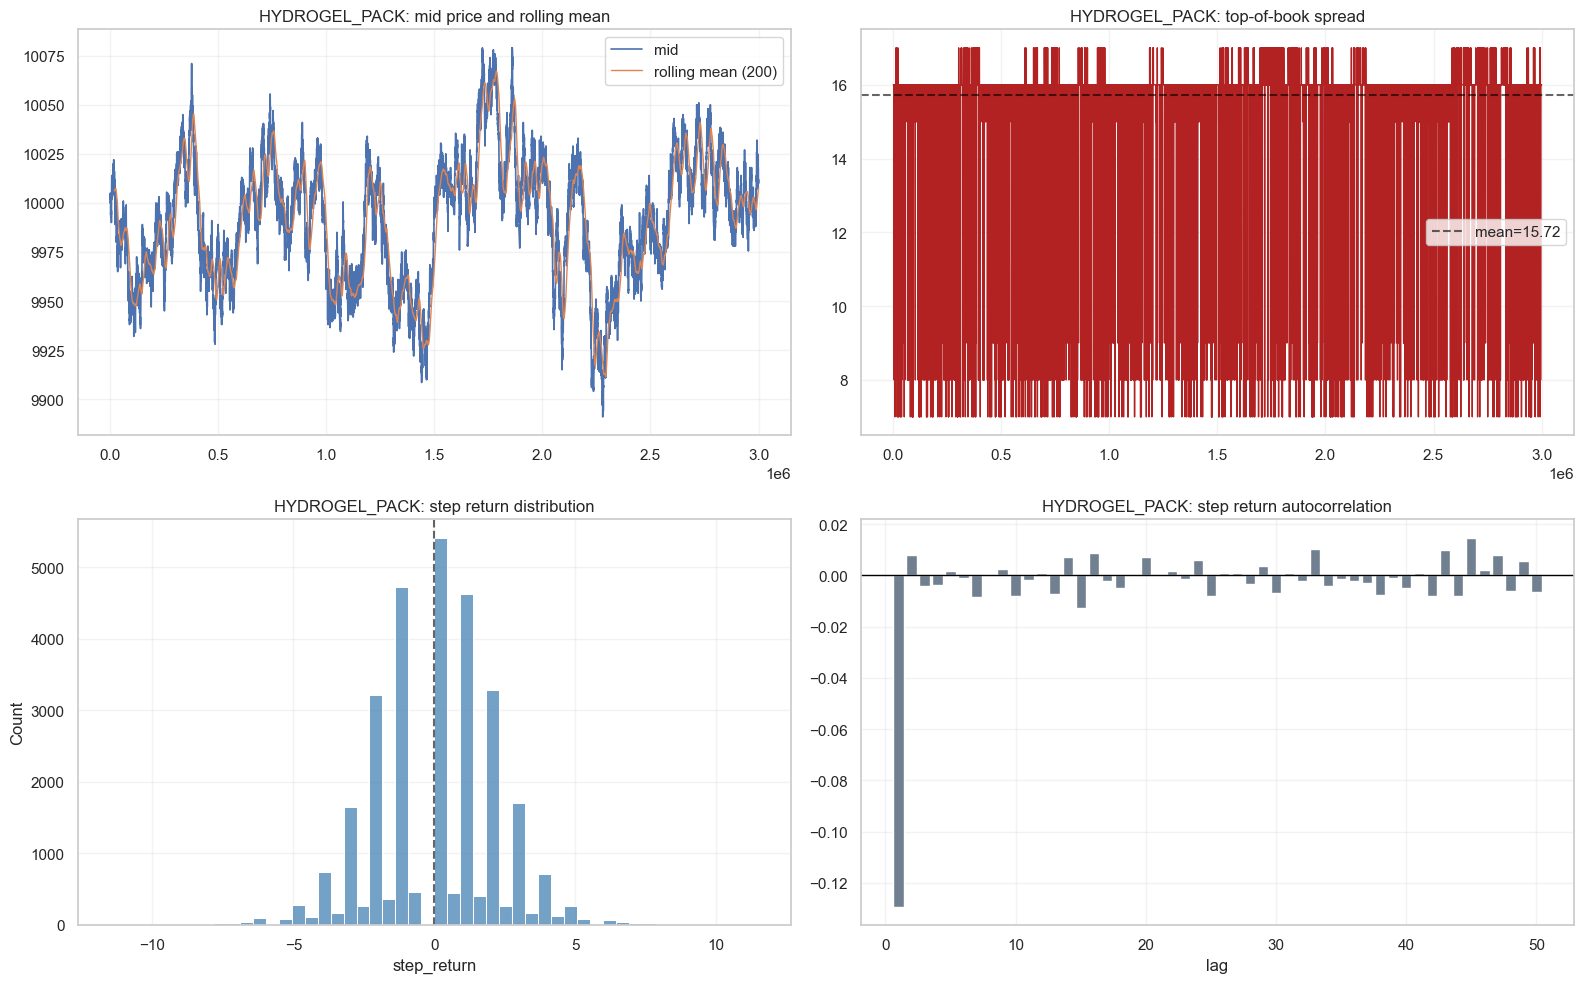

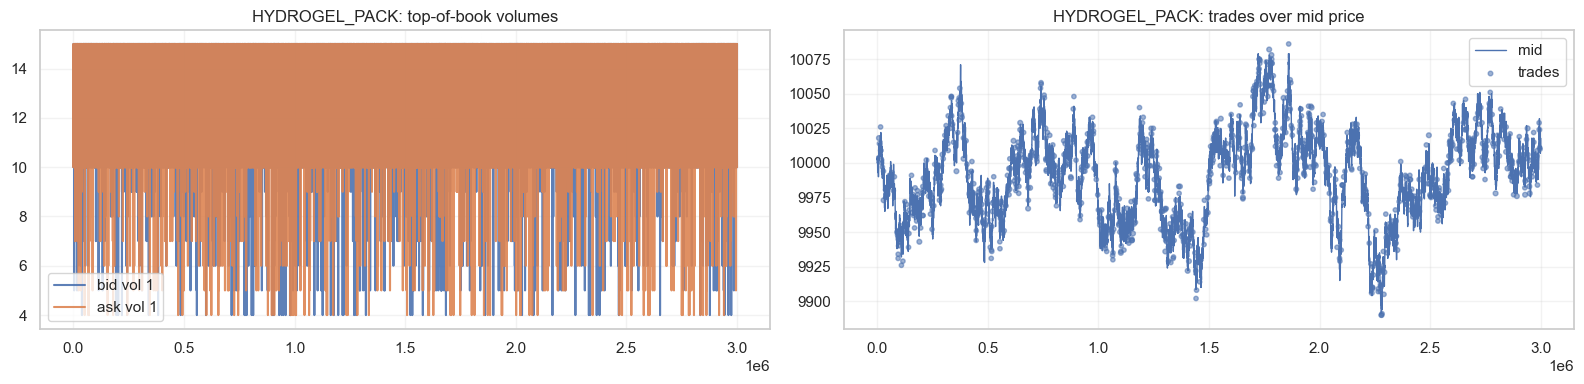

,rows,mid_mean,mid_std,spread_mean,spread_median,spread_pct_1tick,step_ret_std,trade_count,trade_qty_mean
VELVETFRUIT_EXTRACT,30000.0,5250.098,15.63,4.988,5.0,0.006,1.131,1372.0,6.027


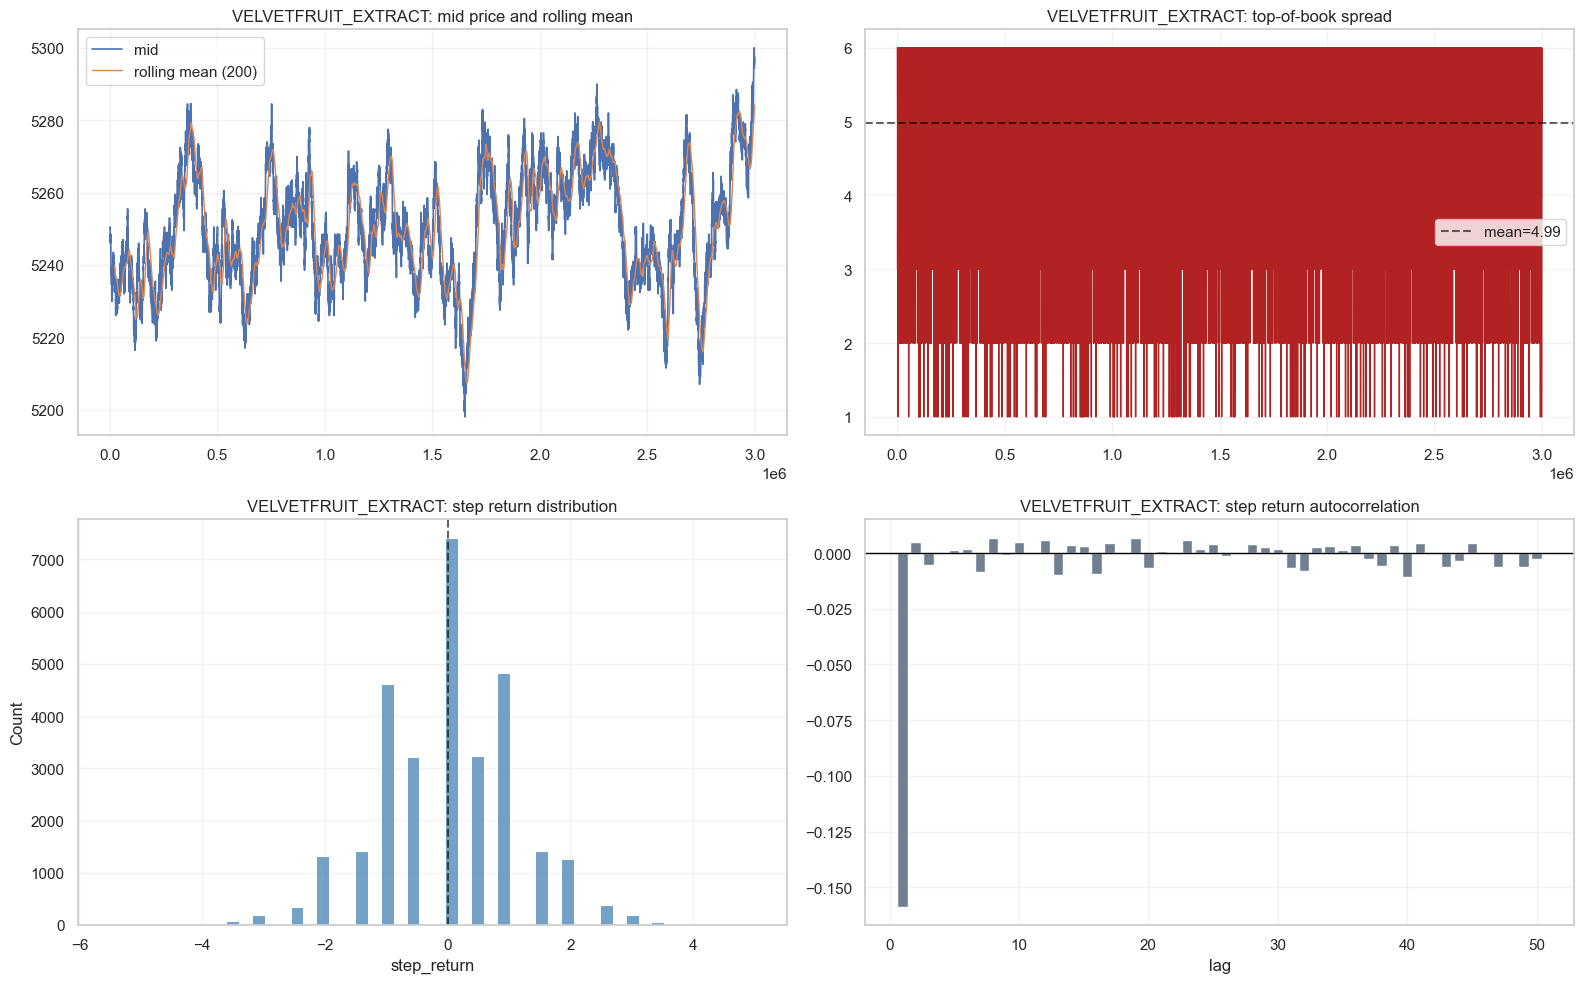

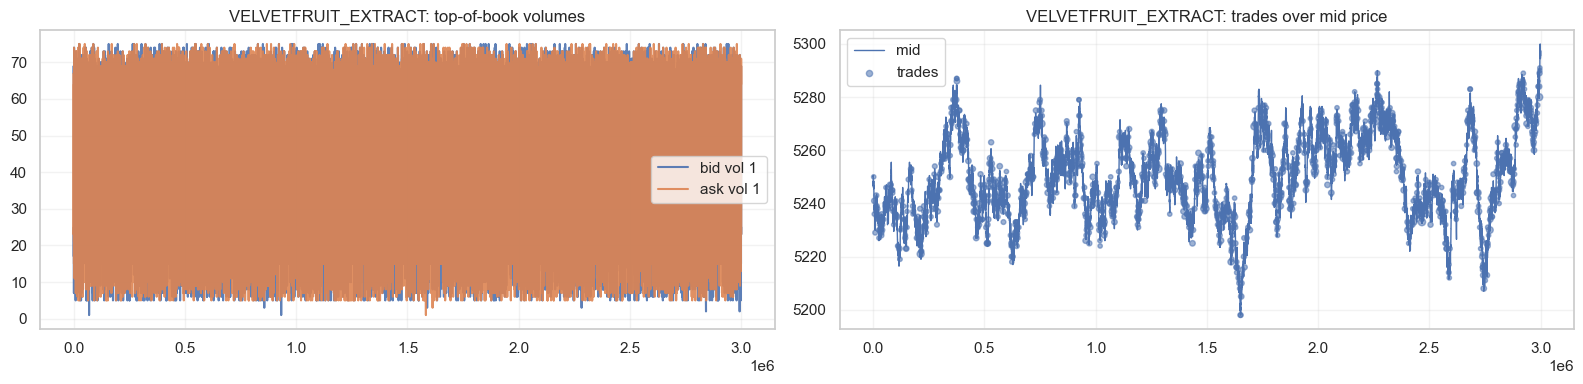

In [5]:

for product in UNDERLYINGS:
    display(summary.loc[[product]].round(3))
    plot_underlying_broad_pass(prices, trades, product)


## Broad Pass: Voucher Family

In [6]:

voucher_summary = (
    vouchers.groupby('product')
    .agg(
        strike=('strike', 'first'),
        tte_days_mean=('tte_days', 'mean'),
        mid_mean=('mid_price', 'mean'),
        mid_std=('mid_price', 'std'),
        spread_mean=('spread', 'mean'),
        intrinsic_mean=('intrinsic', 'mean'),
        time_value_mean=('time_value', 'mean'),
        implied_vol_mean=('implied_vol', 'mean'),
        implied_vol_std=('implied_vol', 'std'),
        trade_count=('trade_count', 'first'),
    )
    .sort_values('strike')
)

display(voucher_summary.round(4))


,strike,tte_days_mean,mid_mean,mid_std,spread_mean,intrinsic_mean,time_value_mean,implied_vol_mean,implied_vol_std,trade_count
product,,,,,,,,,,
VEV_4000,4000.0,7.0,1250.1098,15.6472,20.8135,1250.0981,0.0117,0.7934,0.0911,464
VEV_4500,4500.0,7.0,750.1096,15.6399,15.8527,750.0981,0.0115,0.4497,0.0429,1
VEV_5000,5000.0,7.0,255.0224,14.3756,6.0433,250.0981,4.9243,0.2330,0.0084,1
VEV_5100,5100.0,7.0,166.8054,12.7426,4.2958,150.0981,16.7074,0.2308,0.0076,1
VEV_5200,5200.0,7.0,95.5488,9.6642,2.8881,50.0984,45.4504,0.2333,0.0062,18
VEV_5300,5300.0,7.0,46.7599,6.2281,2.1068,0.0000,46.7599,0.2358,0.0055,121
VEV_5400,5400.0,7.0,15.9519,3.4292,1.3814,0.0000,15.9519,0.2211,0.0071,225
VEV_5500,5500.0,7.0,6.6414,1.7388,1.1498,0.0000,6.6414,0.2398,0.0062,267
VEV_6000,6000.0,7.0,0.5000,0.0000,1.0000,0.0000,0.5000,0.3796,0.0219,284


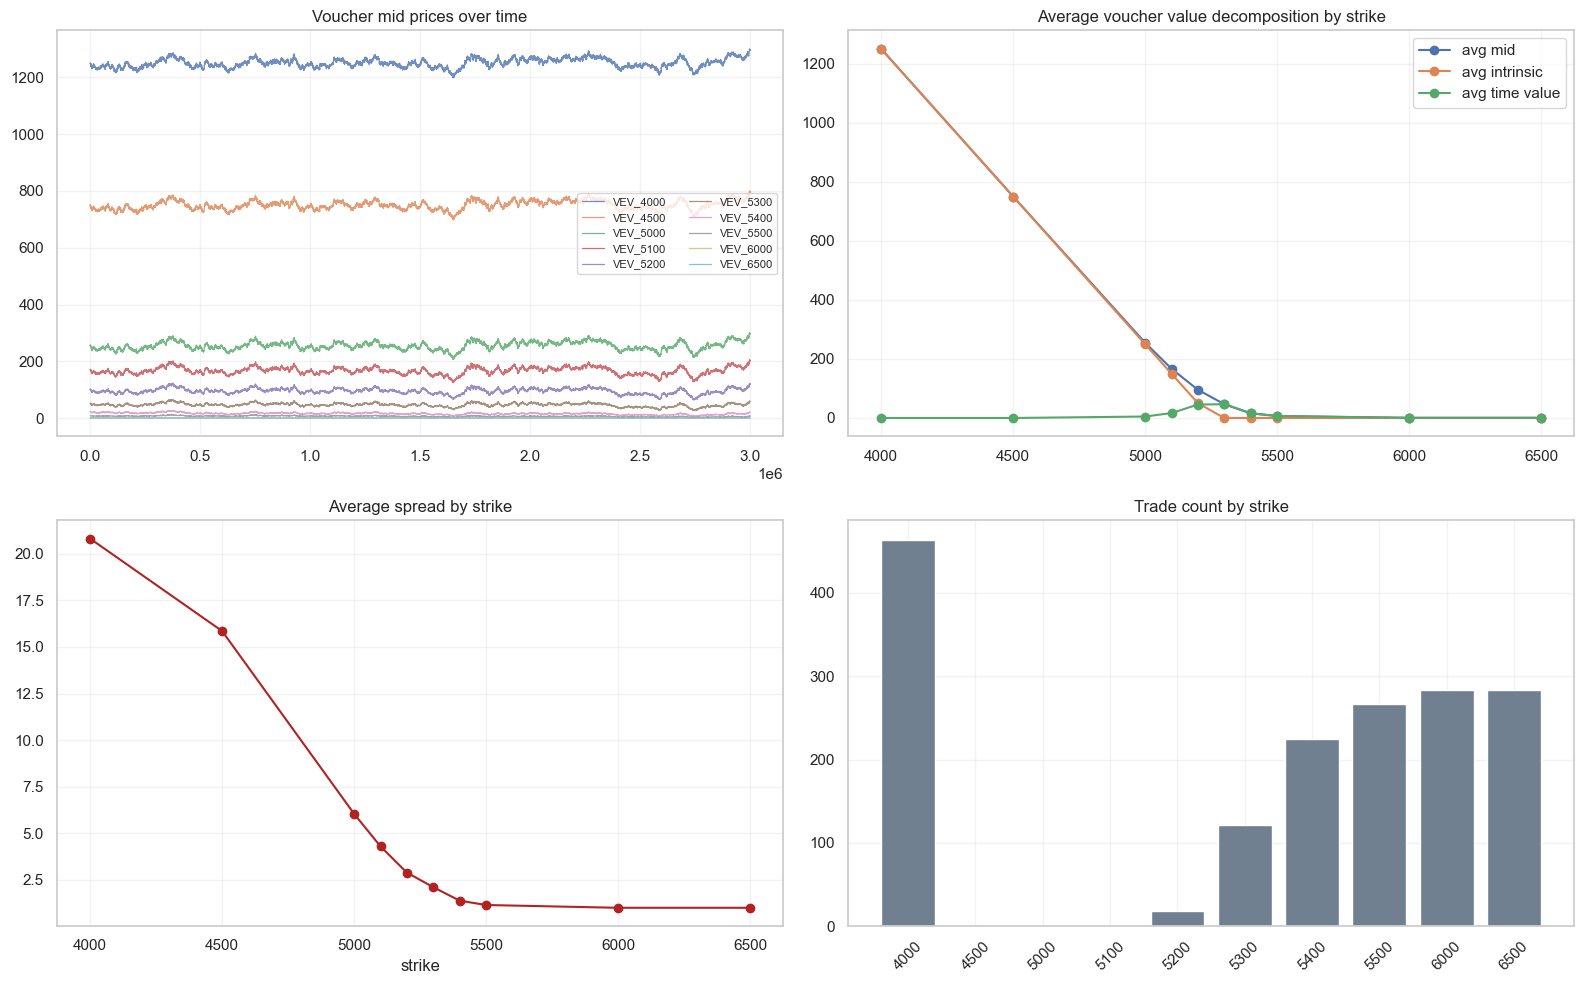

In [7]:

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for product in VOUCHERS:
    sub = vouchers[vouchers['product'] == product]
    axes[0, 0].plot(sub['global_timestamp'], sub['mid_price'], linewidth=0.9, alpha=0.8, label=product)
axes[0, 0].set_title('Voucher mid prices over time')
axes[0, 0].legend(ncol=2, fontsize=8)

axes[0, 1].plot(voucher_summary['strike'], voucher_summary['mid_mean'], marker='o', label='avg mid')
axes[0, 1].plot(voucher_summary['strike'], voucher_summary['intrinsic_mean'], marker='o', label='avg intrinsic')
axes[0, 1].plot(voucher_summary['strike'], voucher_summary['time_value_mean'], marker='o', label='avg time value')
axes[0, 1].set_title('Average voucher value decomposition by strike')
axes[0, 1].legend()

axes[1, 0].plot(voucher_summary['strike'], voucher_summary['spread_mean'], marker='o', color='firebrick')
axes[1, 0].set_title('Average spread by strike')
axes[1, 0].set_xlabel('strike')

axes[1, 1].bar(voucher_summary['strike'].astype(int).astype(str), voucher_summary['trade_count'], color='slategray')
axes[1, 1].set_title('Trade count by strike')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


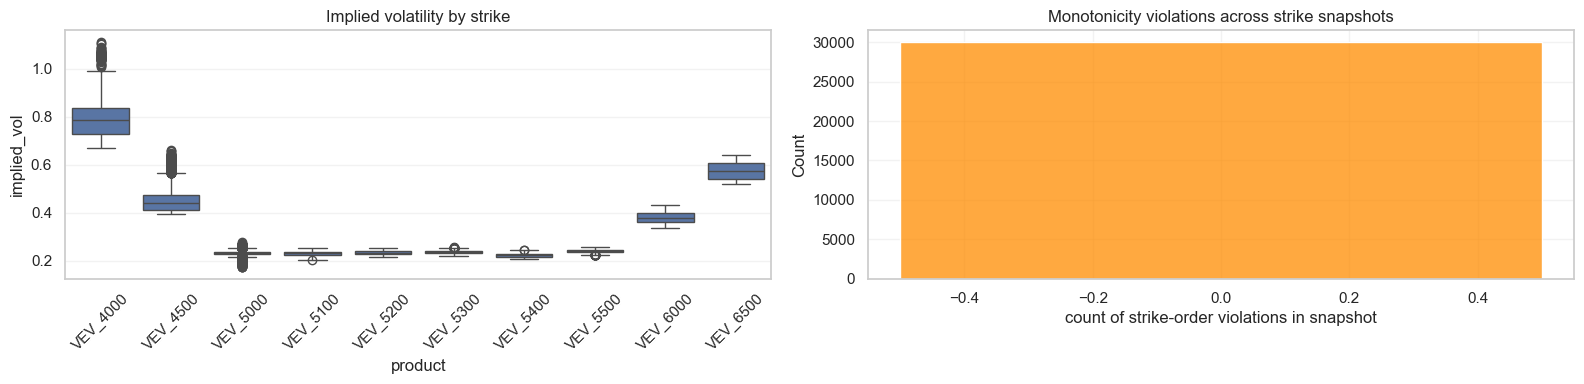

Share of timestamps with at least one strike monotonicity violation: 0.0


In [8]:

fig, axes = plt.subplots(1, 2, figsize=(16, 4))

sample = vouchers.dropna(subset=['implied_vol']).copy()
sns.boxplot(data=sample, x='product', y='implied_vol', order=VOUCHERS, ax=axes[0])
axes[0].set_title('Implied volatility by strike')
axes[0].tick_params(axis='x', rotation=45)

violations = voucher_monotonicity_violations(vouchers)
sns.histplot(violations['violations'], bins=np.arange(-0.5, violations['violations'].max() + 1.5, 1), ax=axes[1], color='darkorange')
axes[1].set_title('Monotonicity violations across strike snapshots')
axes[1].set_xlabel('count of strike-order violations in snapshot')

plt.tight_layout()
plt.show()

print('Share of timestamps with at least one strike monotonicity violation:', (violations['violations'] > 0).mean().round(4))



## First-Pass Questions To Follow Up On

After this broad pass, the main things to test next are:

1. Is `HYDROGEL_PACK` mostly a market-making product, or is there real short-horizon predictability?
2. Is `VELVETFRUIT_EXTRACT` better modeled as a drift process, a mean-reverter, or a mostly efficient anchor for the vouchers?
3. Are voucher opportunities mainly:
   - relative-value across strikes,
   - underlying-vs-voucher mispricing,
   - or simple spread capture in the most active strikes?
4. Are the sparsely traded strikes worth including in the first trader at all?
5. Does the implied vol surface look stable enough to fit, or noisy enough that rank-order and local consistency checks are better than a full model at first?



## Targeted Tests: Delta-1 Products

These tests move beyond broad plots and ask whether there is actual short-horizon structure worth trading.

We focus on:
- lagged return reversion,
- top-of-book imbalance,
- microprice skew,
- rolling z-score reversion.

The point is not to fit a final strategy here. The point is to measure whether the simplest short-horizon signals carry any directional information at all.


HYDROGEL_PACK


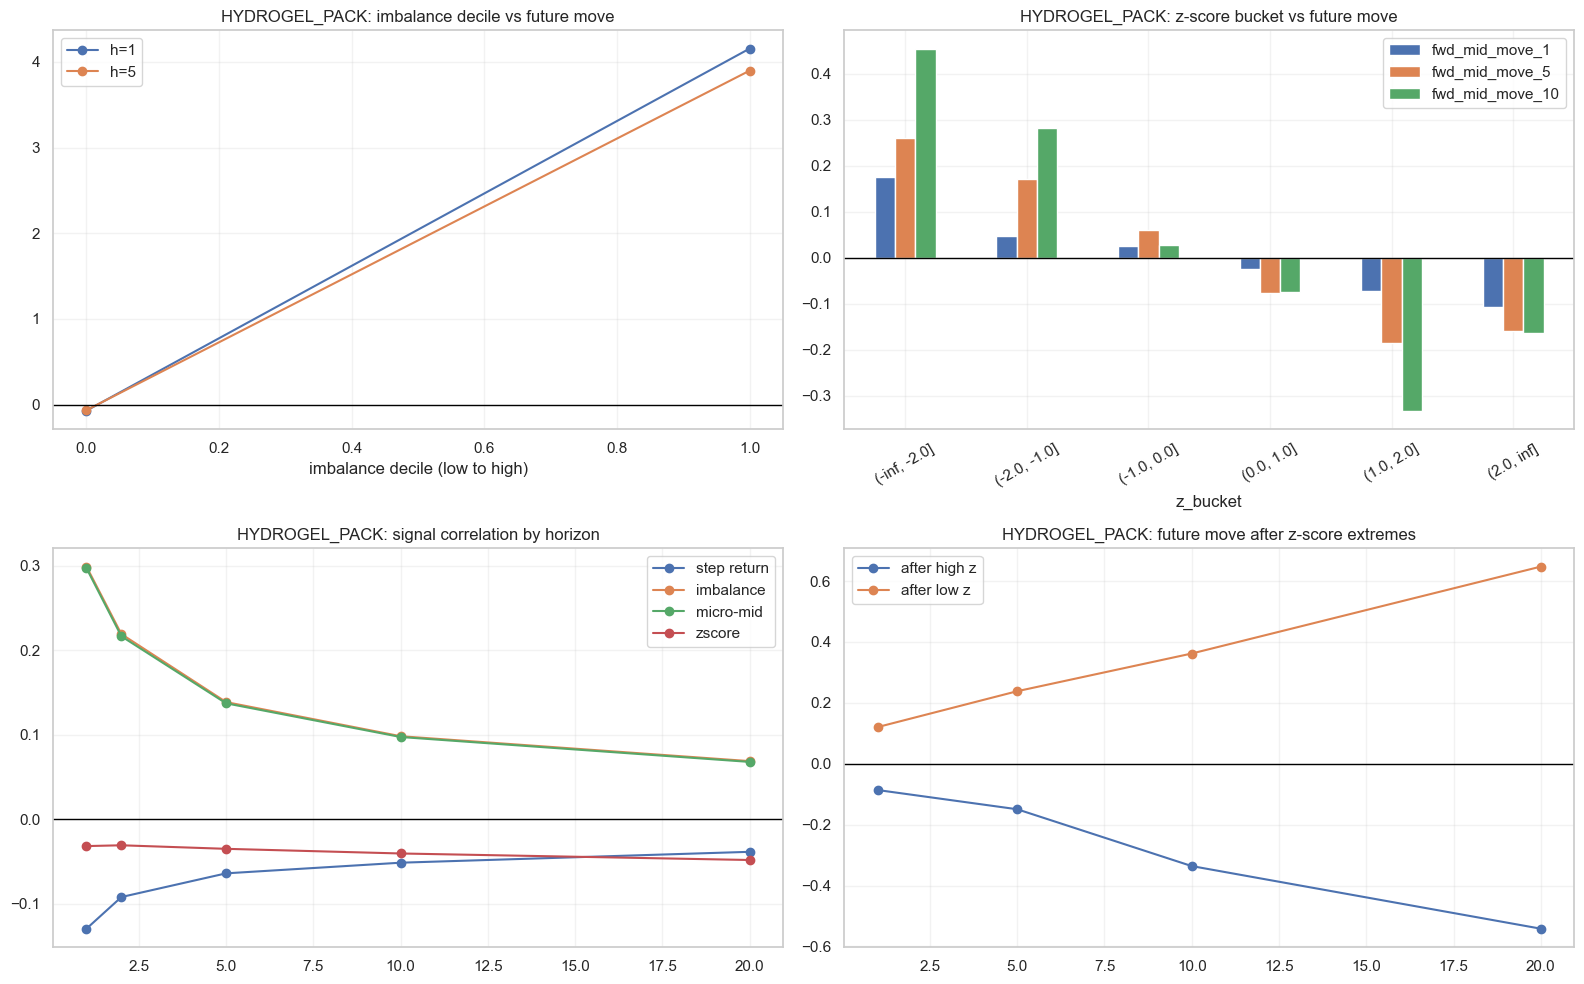

,horizon,"corr(step_return, future_move)","corr(imbalance_1, future_move)","corr(micro_minus_mid, future_move)","corr(zscore_200, future_move)",mean_abs_future_move
0,1,-0.1292,0.2989,0.2970,-0.0315,1.6644
1,2,-0.0918,0.2190,0.2165,-0.0306,2.2528
2,5,-0.0638,0.1387,0.1372,-0.0348,3.4364
3,10,-0.0512,0.0983,0.0974,-0.0403,4.7805
4,20,-0.0383,0.0689,0.0679,-0.0480,6.6779


,horizon,count_high,count_low,avg_future_move_after_high,avg_future_move_after_low,avg_signed_reversion_after_high,avg_signed_reversion_after_low
0,1,4669,4761,-0.0863,0.1204,0.0863,0.1204
1,5,4669,4761,-0.1495,0.2383,0.1495,0.2383
2,10,4669,4761,-0.3362,0.3621,0.3362,0.3621
3,20,4669,4761,-0.5419,0.6477,0.5419,0.6477


VELVETFRUIT_EXTRACT


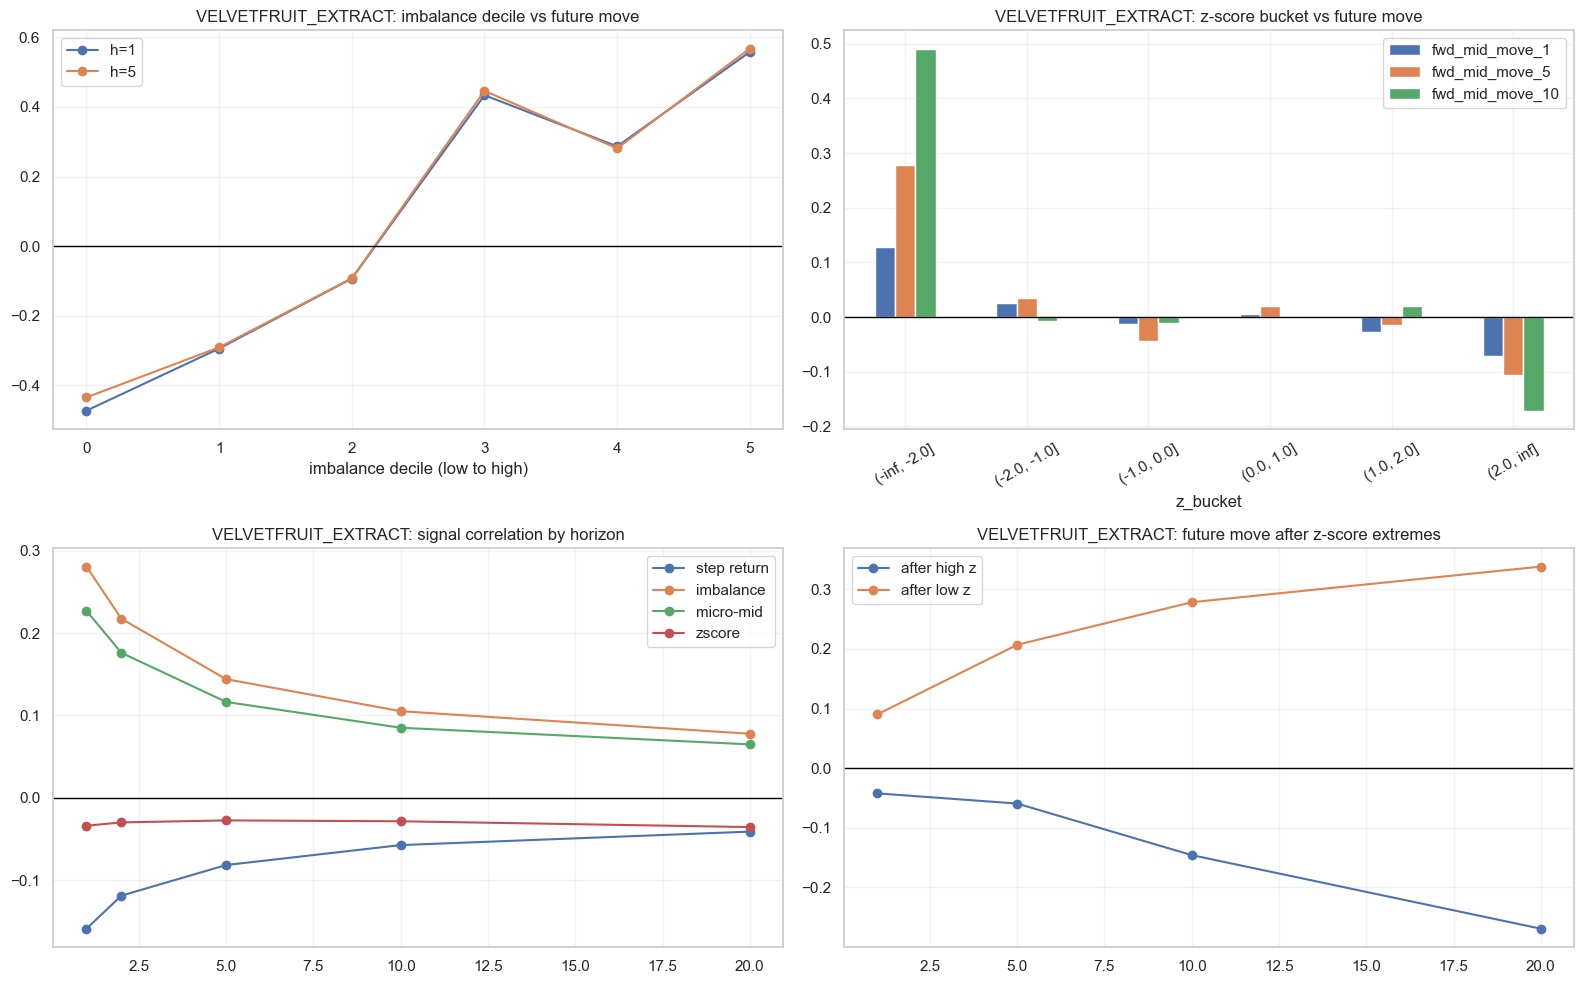

,horizon,"corr(step_return, future_move)","corr(imbalance_1, future_move)","corr(micro_minus_mid, future_move)","corr(zscore_200, future_move)",mean_abs_future_move
0,1,-0.1587,0.2806,0.2270,-0.0337,0.8577
1,2,-0.1186,0.2174,0.1760,-0.0297,1.1396
2,5,-0.0814,0.1441,0.1165,-0.0273,1.7290
3,10,-0.0572,0.1052,0.0851,-0.0283,2.3968
4,20,-0.0409,0.0778,0.0649,-0.0354,3.3860


,horizon,count_high,count_low,avg_future_move_after_high,avg_future_move_after_low,avg_signed_reversion_after_high,avg_signed_reversion_after_low
0,1,4785,4742,-0.0423,0.0903,0.0423,0.0903
1,5,4785,4742,-0.0594,0.2069,0.0594,0.2069
2,10,4785,4742,-0.1458,0.2783,0.1458,0.2783
3,20,4785,4742,-0.2693,0.3380,0.2693,0.3380


In [9]:

TARGET_HORIZONS = [1, 2, 5, 10, 20]


def build_underlying_signal_frame(price_df: pd.DataFrame, product: str, horizons: list[int] = TARGET_HORIZONS) -> pd.DataFrame:
    sub = add_book_features(price_df[price_df['product'] == product].copy())
    sub['imbalance_1'] = (
        sub['bid_volume_1'].abs() - sub['ask_volume_1'].abs()
    ) / (sub['bid_volume_1'].abs() + sub['ask_volume_1'].abs())
    sub['micro_minus_mid'] = sub['microprice'] - sub['mid_price']
    for h in horizons:
        sub[f'fwd_mid_move_{h}'] = sub['mid_price'].shift(-h) - sub['mid_price']
    return sub


def summarize_underlying_signals(sub: pd.DataFrame, horizons: list[int] = TARGET_HORIZONS) -> pd.DataFrame:
    rows = []
    for h in horizons:
        future = sub[f'fwd_mid_move_{h}']
        rows.append({
            'horizon': h,
            'corr(step_return, future_move)': sub['step_return'].corr(future),
            'corr(imbalance_1, future_move)': sub['imbalance_1'].corr(future),
            'corr(micro_minus_mid, future_move)': sub['micro_minus_mid'].corr(future),
            'corr(zscore_200, future_move)': sub['zscore_200'].corr(future),
            'mean_abs_future_move': future.abs().mean(),
        })
    return pd.DataFrame(rows)


def extreme_reversion_table(sub: pd.DataFrame, horizons: list[int] = [1, 5, 10, 20], z_threshold: float = 1.5) -> pd.DataFrame:
    rows = []
    extreme_high = sub['zscore_200'] >= z_threshold
    extreme_low = sub['zscore_200'] <= -z_threshold
    for h in horizons:
        future = sub[f'fwd_mid_move_{h}']
        rows.append({
            'horizon': h,
            'count_high': int(extreme_high.sum()),
            'count_low': int(extreme_low.sum()),
            'avg_future_move_after_high': future[extreme_high].mean(),
            'avg_future_move_after_low': future[extreme_low].mean(),
            'avg_signed_reversion_after_high': (-future[extreme_high]).mean(),
            'avg_signed_reversion_after_low': future[extreme_low].mean(),
        })
    return pd.DataFrame(rows)


def plot_underlying_signal_diagnostics(sub: pd.DataFrame, product: str) -> None:
    summary = summarize_underlying_signals(sub)
    extremes = extreme_reversion_table(sub)

    fig, axes = plt.subplots(2, 2, figsize=(16, 10))

    imbalance_bins = pd.qcut(sub['imbalance_1'], q=10, duplicates='drop')
    imbalance_bucket = sub.groupby(imbalance_bins)[['fwd_mid_move_1', 'fwd_mid_move_5']].mean().reset_index(drop=True)
    axes[0, 0].plot(range(len(imbalance_bucket)), imbalance_bucket['fwd_mid_move_1'], marker='o', label='h=1')
    axes[0, 0].plot(range(len(imbalance_bucket)), imbalance_bucket['fwd_mid_move_5'], marker='o', label='h=5')
    axes[0, 0].axhline(0, color='black', linewidth=1)
    axes[0, 0].set_title(f'{product}: imbalance decile vs future move')
    axes[0, 0].set_xlabel('imbalance decile (low to high)')
    axes[0, 0].legend()

    z = sub[['zscore_200', 'fwd_mid_move_1', 'fwd_mid_move_5', 'fwd_mid_move_10']].dropna().copy()
    z['z_bucket'] = pd.cut(z['zscore_200'], bins=[-np.inf, -2, -1, 0, 1, 2, np.inf])
    z_bucket = z.groupby('z_bucket')[['fwd_mid_move_1', 'fwd_mid_move_5', 'fwd_mid_move_10']].mean()
    z_bucket.plot(kind='bar', ax=axes[0, 1])
    axes[0, 1].axhline(0, color='black', linewidth=1)
    axes[0, 1].set_title(f'{product}: z-score bucket vs future move')
    axes[0, 1].tick_params(axis='x', rotation=30)

    axes[1, 0].plot(summary['horizon'], summary['corr(step_return, future_move)'], marker='o', label='step return')
    axes[1, 0].plot(summary['horizon'], summary['corr(imbalance_1, future_move)'], marker='o', label='imbalance')
    axes[1, 0].plot(summary['horizon'], summary['corr(micro_minus_mid, future_move)'], marker='o', label='micro-mid')
    axes[1, 0].plot(summary['horizon'], summary['corr(zscore_200, future_move)'], marker='o', label='zscore')
    axes[1, 0].axhline(0, color='black', linewidth=1)
    axes[1, 0].set_title(f'{product}: signal correlation by horizon')
    axes[1, 0].legend()

    axes[1, 1].plot(extremes['horizon'], extremes['avg_future_move_after_high'], marker='o', label='after high z')
    axes[1, 1].plot(extremes['horizon'], extremes['avg_future_move_after_low'], marker='o', label='after low z')
    axes[1, 1].axhline(0, color='black', linewidth=1)
    axes[1, 1].set_title(f'{product}: future move after z-score extremes')
    axes[1, 1].legend()

    plt.tight_layout()
    plt.show()

    display(summary.round(4))
    display(extremes.round(4))


underlying_signal_frames = {product: build_underlying_signal_frame(prices, product) for product in UNDERLYINGS}

for product, sub in underlying_signal_frames.items():
    print(product)
    plot_underlying_signal_diagnostics(sub, product)



## Targeted Tests: Voucher Surface and Fair-Value Anchors

This section compares several fair-value anchors for the vouchers:
- a pooled global quadratic smile,
- a timestamp-local quadratic smile fitted cross-sectionally,
- a rolling per-strike IV anchor.

For each anchor we care about two things:
1. residual size: how large are option price deviations from the anchor?
2. residual behavior: do those deviations mean-revert enough to be tradable?

A good-looking IV plot is not enough. The anchor has to produce residuals that behave like opportunities rather than noise.


In [10]:

vouchers['mid_iv'] = [
    implied_vol_call(price, spot, strike, tte)
    for price, spot, strike, tte in zip(vouchers['mid_price'], vouchers['underlying_mid'], vouchers['strike'], vouchers['tte_days'])
]
vouchers['fit_eligible'] = vouchers['mid_iv'].notna() & (vouchers['time_value'] > 1.0)
vouchers['moneyness_iv'] = np.log(vouchers['underlying_mid'] / vouchers['strike']) / np.sqrt(vouchers['tte_days'] / 365.0)


def fit_quadratic_smile(m: np.ndarray, iv: np.ndarray) -> tuple[float, float, float] | tuple[float, float, float]:
    mask = np.isfinite(m) & np.isfinite(iv)
    if mask.sum() < 3:
        return (np.nan, np.nan, np.nan)
    X = np.column_stack([m[mask] ** 2, m[mask], np.ones(mask.sum())])
    coef, *_ = np.linalg.lstsq(X, iv[mask], rcond=None)
    return tuple(coef)


def predict_quadratic_smile(m: pd.Series, coeffs: tuple[float, float, float]) -> pd.Series:
    a, b, c = coeffs
    return a * (m ** 2) + b * m + c


global_fit_df = vouchers[vouchers['fit_eligible']].copy()
global_coeffs = fit_quadratic_smile(global_fit_df['moneyness_iv'].to_numpy(), global_fit_df['mid_iv'].to_numpy())
print('Global smile coefficients (a, b, c):', tuple(round(x, 6) for x in global_coeffs))

vouchers['fair_iv_global'] = predict_quadratic_smile(vouchers['moneyness_iv'], global_coeffs)

local_coeff_rows = []
for (day, ts), snap in vouchers.groupby(['day', 'timestamp']):
    fit_snap = snap[snap['fit_eligible']]
    coeffs = fit_quadratic_smile(fit_snap['moneyness_iv'].to_numpy(), fit_snap['mid_iv'].to_numpy())
    local_coeff_rows.append({'day': day, 'timestamp': ts, 'a_local': coeffs[0], 'b_local': coeffs[1], 'c_local': coeffs[2]})

local_coeffs = pd.DataFrame(local_coeff_rows)
vouchers = vouchers.merge(local_coeffs, on=['day', 'timestamp'], how='left')
vouchers['fair_iv_local'] = vouchers['a_local'] * vouchers['moneyness_iv'] ** 2 + vouchers['b_local'] * vouchers['moneyness_iv'] + vouchers['c_local']

vouchers['fair_iv_rolling_strike'] = (
    vouchers.groupby('product')['mid_iv']
    .transform(lambda s: s.rolling(100, min_periods=20).mean())
)

for label in ['global', 'local', 'rolling_strike']:
    vouchers[f'fair_price_{label}'] = [
        black_scholes_call_price(spot, strike, tte, sigma)
        if np.isfinite(sigma) else np.nan
        for spot, strike, tte, sigma in zip(
            vouchers['underlying_mid'],
            vouchers['strike'],
            vouchers['tte_days'],
            vouchers[f'fair_iv_{label}'],
        )
    ]
    vouchers[f'price_resid_{label}'] = vouchers['mid_price'] - vouchers[f'fair_price_{label}']


Global smile coefficients (a, b, c): (np.float64(0.164405), np.float64(0.004254), np.float64(0.223585))


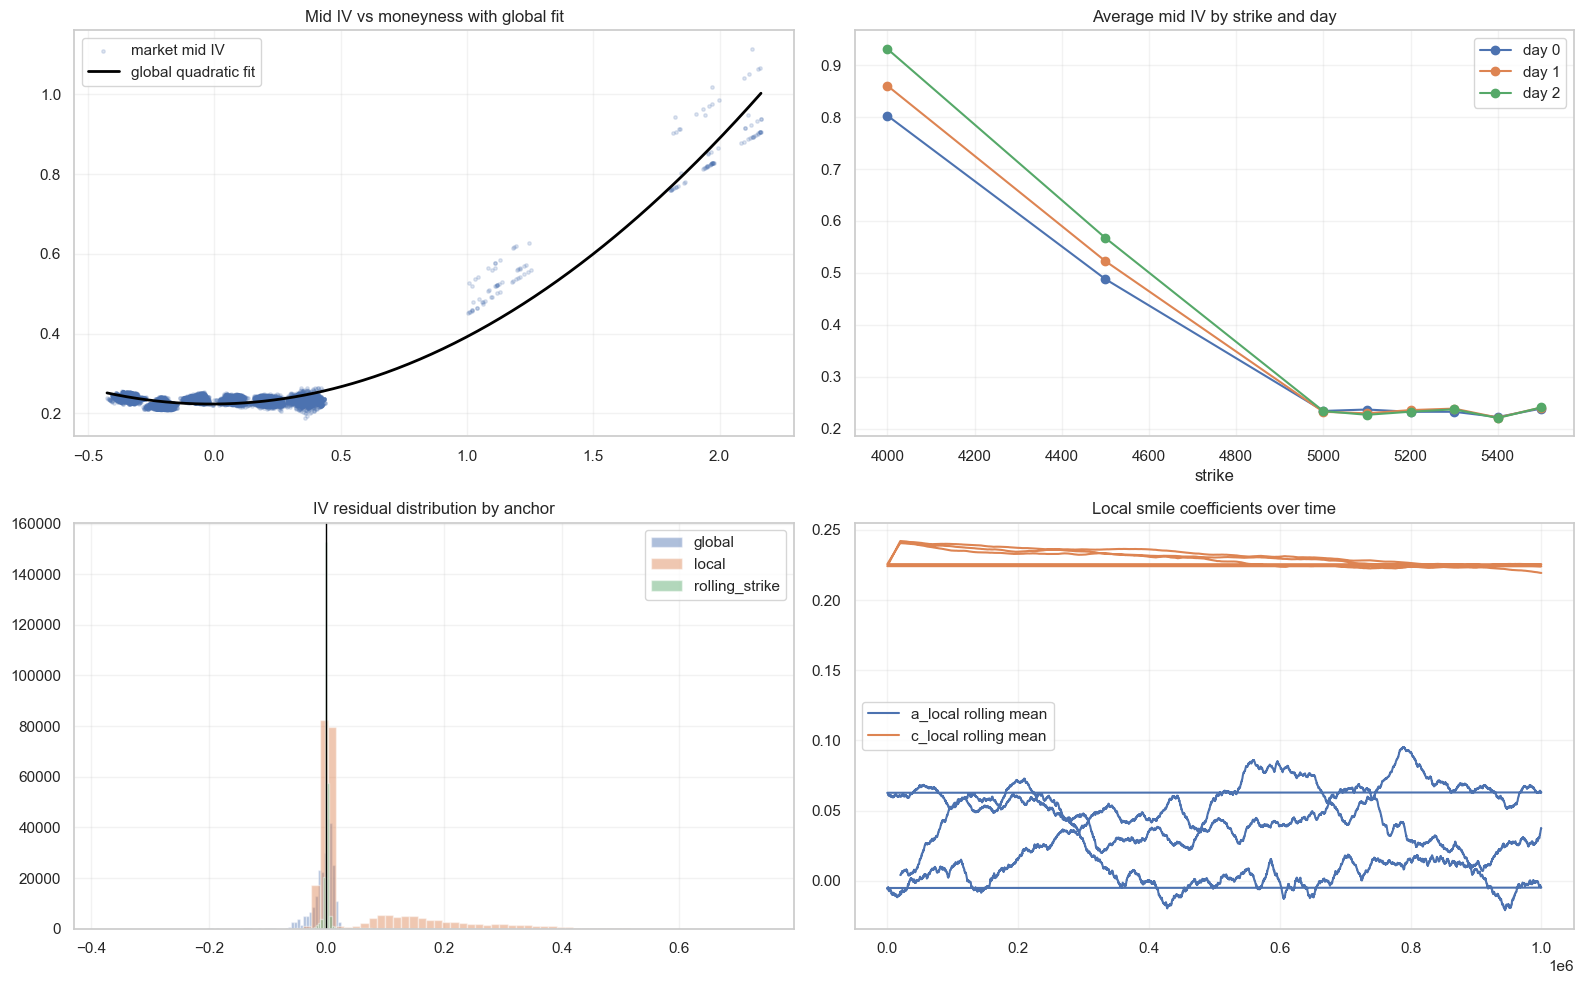

In [11]:

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

sample = vouchers[vouchers['fit_eligible']].sample(min(12000, vouchers['fit_eligible'].sum()), random_state=0)
axes[0, 0].scatter(sample['moneyness_iv'], sample['mid_iv'], s=6, alpha=0.18, label='market mid IV')
xs = np.linspace(sample['moneyness_iv'].min(), sample['moneyness_iv'].max(), 400)
a, b, c = global_coeffs
axes[0, 0].plot(xs, a * xs**2 + b * xs + c, color='black', linewidth=2, label='global quadratic fit')
axes[0, 0].set_title('Mid IV vs moneyness with global fit')
axes[0, 0].legend()

for day in sorted(vouchers['day'].unique()):
    day_df = vouchers[(vouchers['day'] == day) & vouchers['fit_eligible']]
    day_group = day_df.groupby('product')['mid_iv'].mean().reindex(VOUCHERS)
    axes[0, 1].plot([strike_from_symbol(v) for v in VOUCHERS], day_group.values, marker='o', label=f'day {day}')
axes[0, 1].set_title('Average mid IV by strike and day')
axes[0, 1].set_xlabel('strike')
axes[0, 1].legend()

for label in ['fair_iv_global', 'fair_iv_local', 'fair_iv_rolling_strike']:
    diff = vouchers['mid_iv'] - vouchers[label]
    axes[1, 0].hist(diff.dropna(), bins=80, alpha=0.45, label=label.replace('fair_iv_', ''))
axes[1, 0].axvline(0, color='black', linewidth=1)
axes[1, 0].set_title('IV residual distribution by anchor')
axes[1, 0].legend()

local_coef_sample = local_coeffs.dropna().copy()
axes[1, 1].plot(local_coef_sample['timestamp'] + local_coef_sample['day'] * 0, local_coef_sample['a_local'].rolling(200).mean(), label='a_local rolling mean')
axes[1, 1].plot(local_coef_sample['timestamp'] + local_coef_sample['day'] * 0, local_coef_sample['c_local'].rolling(200).mean(), label='c_local rolling mean')
axes[1, 1].set_title('Local smile coefficients over time')
axes[1, 1].legend()

plt.tight_layout()
plt.show()


In [12]:

anchor_summary_rows = []
for label in ['global', 'local', 'rolling_strike']:
    resid = vouchers[f'price_resid_{label}']
    anchor_summary_rows.append({
        'anchor': label,
        'coverage': resid.notna().mean(),
        'mae_price_resid': resid.abs().mean(),
        'rmse_price_resid': np.sqrt(np.nanmean(resid**2)),
        'lag1_resid_autocorr': resid.dropna().autocorr(lag=1),
        'lag5_resid_autocorr': resid.dropna().autocorr(lag=5),
    })
anchor_summary = pd.DataFrame(anchor_summary_rows)
display(anchor_summary.round(4))


,anchor,coverage,mae_price_resid,rmse_price_resid,lag1_resid_autocorr,lag5_resid_autocorr
0,global,1.0000,1.3982,1.9319,0.3211,-0.3991
1,local,1.0000,0.7539,1.0981,-0.2062,-0.0133
2,rolling_strike,0.8899,0.2587,0.4537,0.4151,0.0400


In [13]:

ACTIVE_VOUCHERS = (
    vouchers.groupby('product')
    .agg(
        strike=('strike', 'first'),
        spread_mean=('spread', 'mean'),
        time_value_mean=('time_value', 'mean'),
        trade_count=('trade_count', 'first'),
    )
    .query('trade_count >= 20')
    .sort_values('strike')
    .index.tolist()
)

print('Active voucher subset:', ACTIVE_VOUCHERS)


def residual_reversion_stats(vdf: pd.DataFrame, resid_col: str, horizons: list[int] = [1, 2, 5, 10, 20]) -> pd.DataFrame:
    rows = []
    tmp = vdf.sort_values('global_timestamp').copy()
    resid = tmp[resid_col]
    resid_std = resid.std()
    if not np.isfinite(resid_std) or resid_std == 0:
        return pd.DataFrame()
    high = resid >= resid_std
    low = resid <= -resid_std
    for h in horizons:
        future_resid = resid.shift(-h)
        delta = future_resid - resid
        rows.append({
            'horizon': h,
            'count_high': int(high.sum()),
            'count_low': int(low.sum()),
            'avg_delta_after_high': delta[high].mean(),
            'avg_delta_after_low': delta[low].mean(),
            'avg_reversion_after_high': (-delta[high]).mean(),
            'avg_reversion_after_low': delta[low].mean(),
            'corr(resid, future_resid_change)': resid.corr(delta),
        })
    return pd.DataFrame(rows)


resid_model = 'price_resid_local'
reversion_tables = {}
for voucher in ACTIVE_VOUCHERS:
    vdf = vouchers[vouchers['product'] == voucher].copy()
    reversion_tables[voucher] = residual_reversion_stats(vdf, resid_model)

reversion_summary = pd.concat(
    [
        tbl.assign(product=product)
        for product, tbl in reversion_tables.items()
        if not tbl.empty
    ],
    ignore_index=True,
)

display(reversion_summary.round(4))


Active voucher subset: ['VEV_4000', 'VEV_5300', 'VEV_5400', 'VEV_5500', 'VEV_6000', 'VEV_6500']


,horizon,count_high,count_low,avg_delta_after_high,avg_delta_after_low,avg_reversion_after_high,avg_reversion_after_low,"corr(resid, future_resid_change)",product
0,1,19,1442,-1.0154,1.8899,1.0154,1.8899,-0.7065,VEV_4000
1,2,19,1442,-0.9961,1.8813,0.9961,1.8813,-0.7067,VEV_4000
2,5,19,1442,-1.2249,1.8678,1.2249,1.8678,-0.7039,VEV_4000
3,10,19,1442,-1.0695,1.8636,1.0695,1.8636,-0.7062,VEV_4000
4,20,19,1442,-1.3364,1.8712,1.3364,1.8712,-0.7067,VEV_4000
5,1,22093,1,-0.0361,1.1390,0.0361,1.1390,-0.2701,VEV_5300
6,2,22093,1,-0.0360,1.4418,0.0360,1.4418,-0.2734,VEV_5300
7,5,22093,1,-0.0365,1.2703,0.0365,1.2703,-0.2738,VEV_5300
8,10,22093,1,-0.0364,1.4073,0.0364,1.4073,-0.2753,VEV_5300
9,20,22093,1,-0.0366,1.2054,0.0366,1.2054,-0.2772,VEV_5300


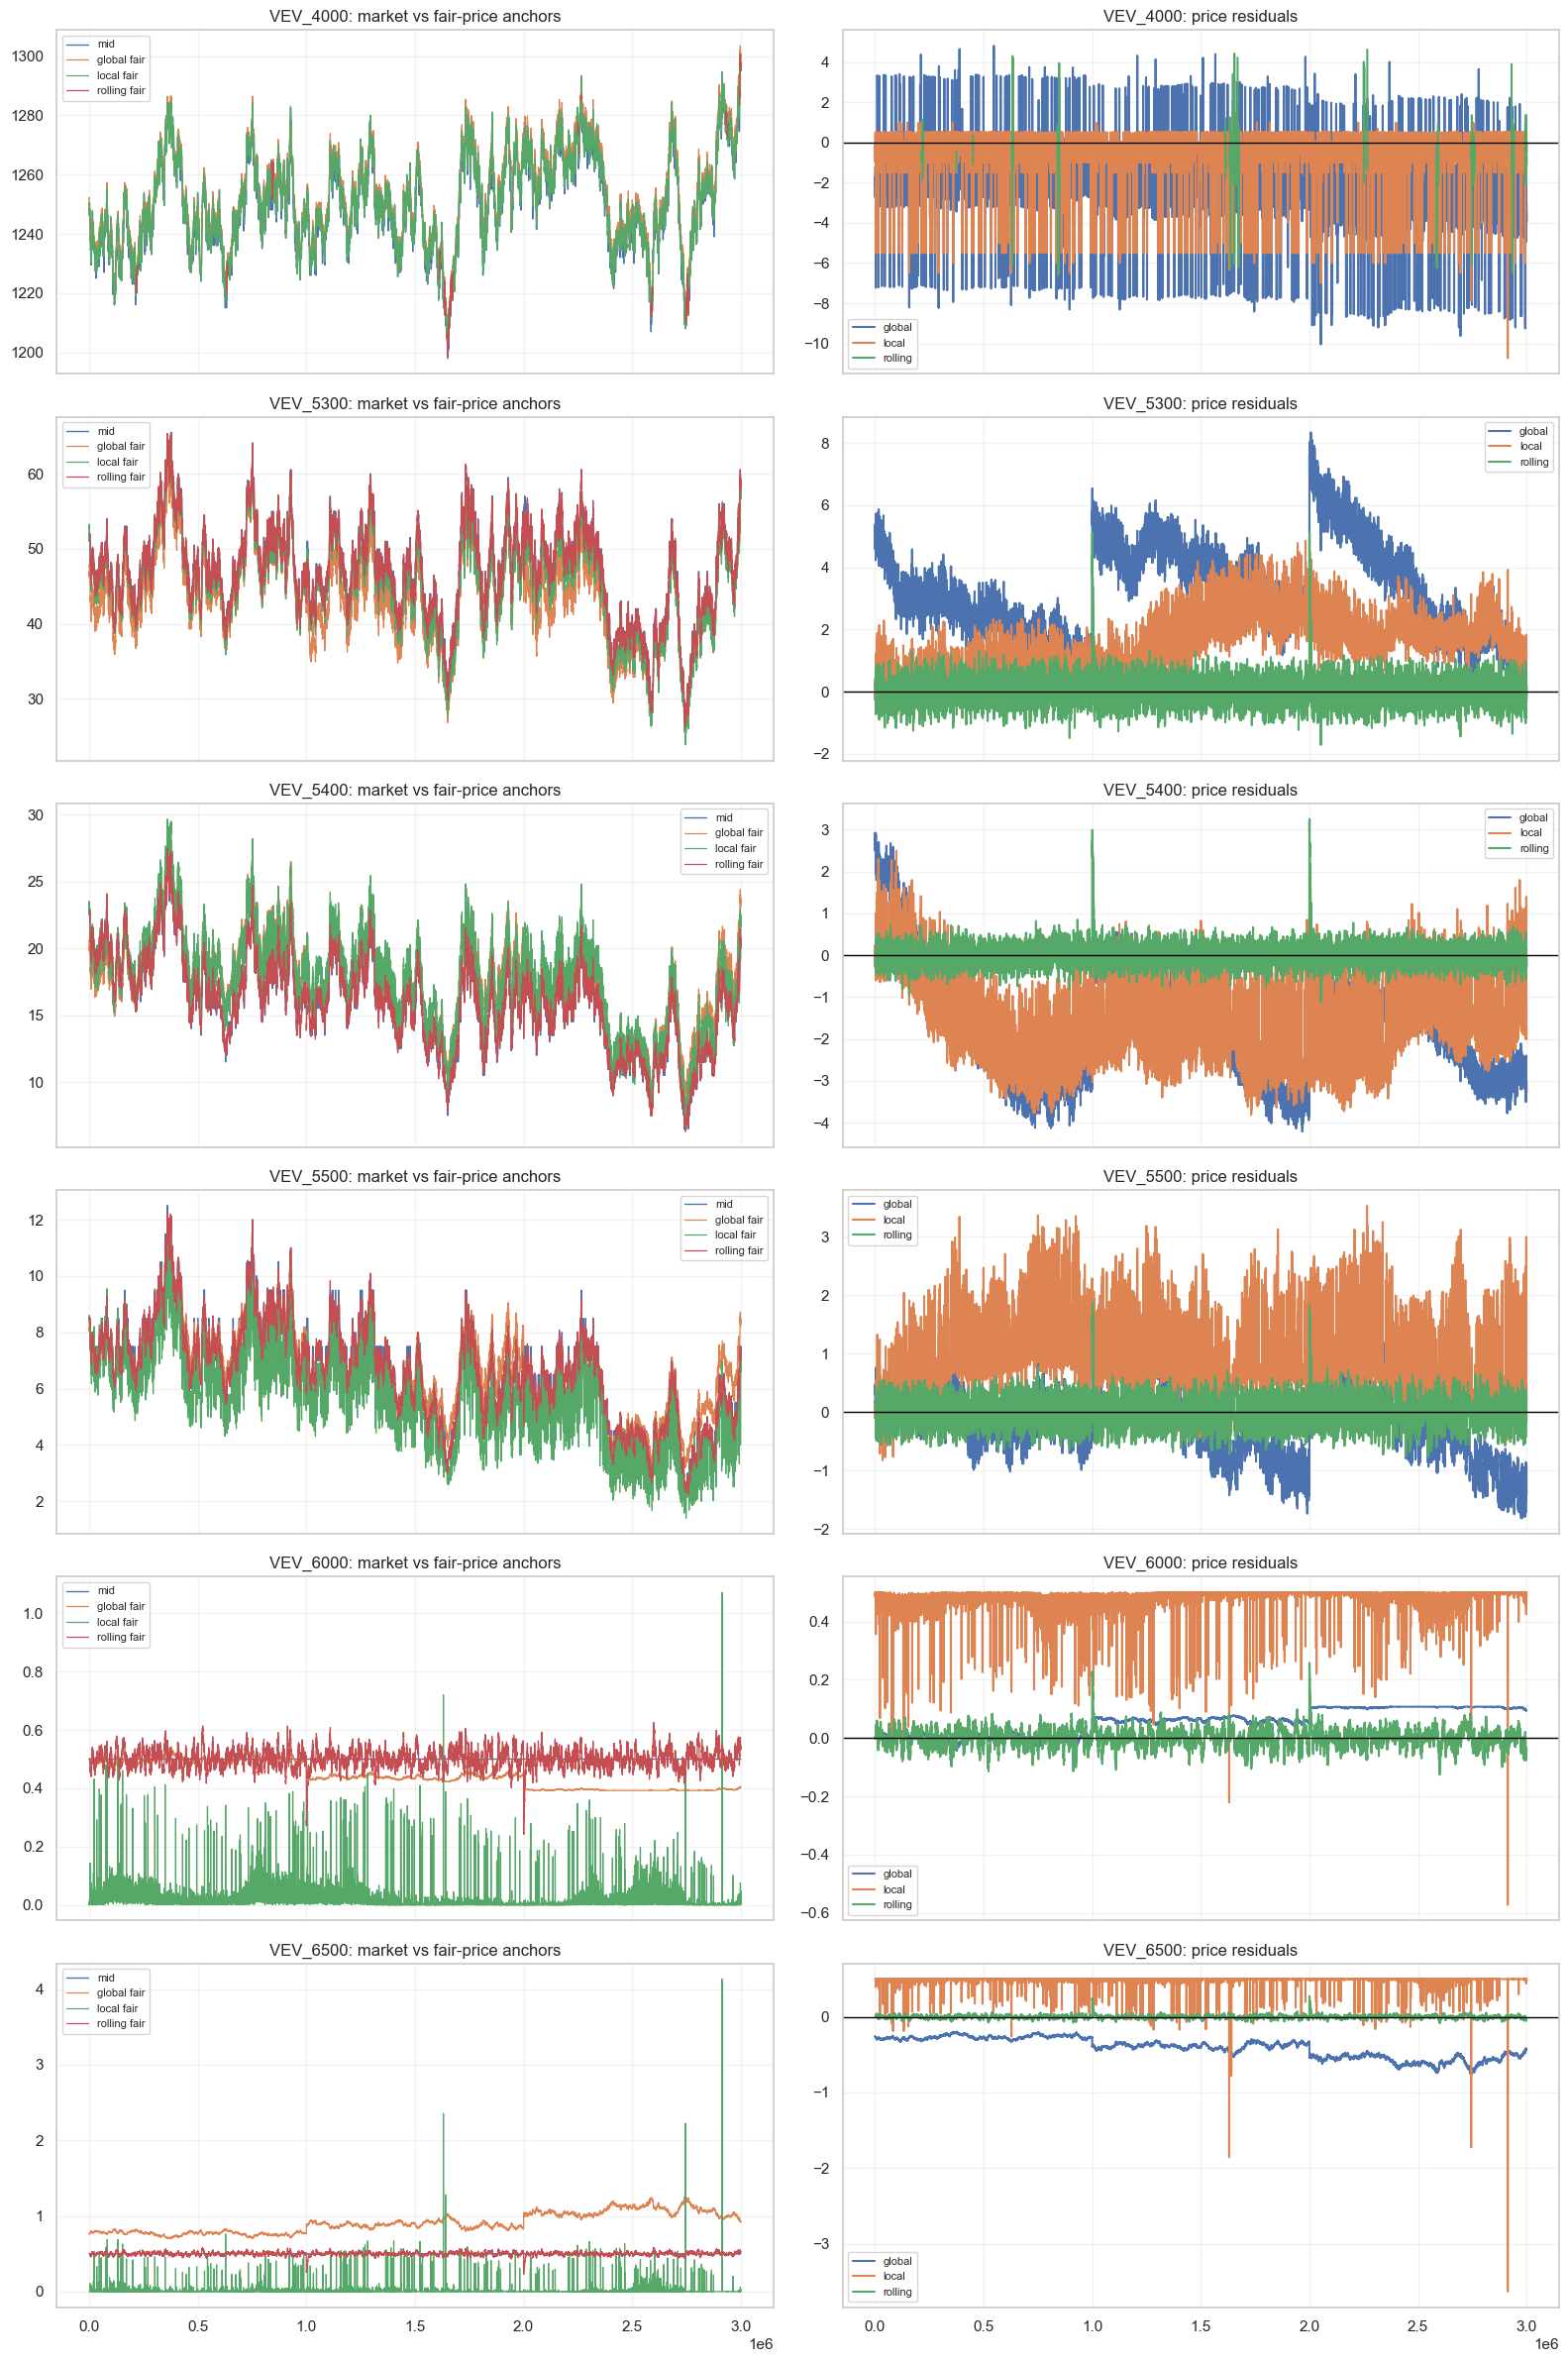

In [14]:

fig, axes = plt.subplots(len(ACTIVE_VOUCHERS), 2, figsize=(16, 4 * len(ACTIVE_VOUCHERS)), sharex='col')
if len(ACTIVE_VOUCHERS) == 1:
    axes = np.array([axes])

for i, voucher in enumerate(ACTIVE_VOUCHERS):
    vdf = vouchers[vouchers['product'] == voucher].copy().sort_values('global_timestamp')
    axes[i, 0].plot(vdf['global_timestamp'], vdf['mid_price'], label='mid', linewidth=1.0)
    axes[i, 0].plot(vdf['global_timestamp'], vdf['fair_price_global'], label='global fair', linewidth=0.9)
    axes[i, 0].plot(vdf['global_timestamp'], vdf['fair_price_local'], label='local fair', linewidth=0.9)
    axes[i, 0].plot(vdf['global_timestamp'], vdf['fair_price_rolling_strike'], label='rolling fair', linewidth=0.9)
    axes[i, 0].set_title(f'{voucher}: market vs fair-price anchors')
    axes[i, 0].legend(fontsize=8)

    axes[i, 1].plot(vdf['global_timestamp'], vdf['price_resid_global'], label='global')
    axes[i, 1].plot(vdf['global_timestamp'], vdf['price_resid_local'], label='local')
    axes[i, 1].plot(vdf['global_timestamp'], vdf['price_resid_rolling_strike'], label='rolling')
    axes[i, 1].axhline(0, color='black', linewidth=1)
    axes[i, 1].set_title(f'{voucher}: price residuals')
    axes[i, 1].legend(fontsize=8)

plt.tight_layout()
plt.show()



## Interim Interpretation Template

After the targeted tests above, the next conclusions we want to write down explicitly are:
- which delta-1 product has the clearest short-horizon signal,
- which voucher fair-value anchor is least bad,
- which strikes actually exhibit residual mean reversion after adjusting for fair value,
- and whether a first implementation should emphasize:
  - spread capture,
  - fair-value taking,
  - relative-value across strikes,
  - or a mix.



## Vectorized Sanity Checks: Underlying Take and Make Logic

These are deliberately simple tests. They are not full backtests.

For each underlying we test whether directional signals from book imbalance and microprice skew have enough edge to survive:
- aggressive entry at the current best ask/bid,
- or optimistic passive entry at the current best bid/ask,
- with exit marked to the future mid price.

This gives us a first answer to whether the products are worth treating as signal-driven takers, pure market makers, or both.


In [15]:

UNDERLYING_THRESHOLDS = [0.10, 0.20, 0.30, 0.40]
UNDERLYING_HORIZONS = [1, 2, 5, 10, 20]


def evaluate_underlying_signal_strategy(sub: pd.DataFrame, signal_col: str, thresholds: list[float], horizons: list[int], mode: str) -> pd.DataFrame:
    rows = []
    for thr in thresholds:
        long_mask = sub[signal_col] >= thr
        short_mask = sub[signal_col] <= -thr
        for h in horizons:
            future_mid = sub[f'fwd_mid_move_{h}'] + sub['mid_price']
            if mode == 'take':
                long_pnl = future_mid - sub['ask_price_1']
                short_pnl = sub['bid_price_1'] - future_mid
            elif mode == 'make':
                long_pnl = future_mid - sub['bid_price_1']
                short_pnl = sub['ask_price_1'] - future_mid
            else:
                raise ValueError(mode)

            pnl = pd.concat([long_pnl[long_mask], short_pnl[short_mask]])
            rows.append({
                'signal': signal_col,
                'mode': mode,
                'threshold': thr,
                'horizon': h,
                'count_long': int(long_mask.sum()),
                'count_short': int(short_mask.sum()),
                'count_total': int(long_mask.sum() + short_mask.sum()),
                'mean_pnl': pnl.mean(),
                'median_pnl': pnl.median(),
                'win_rate': (pnl > 0).mean(),
            })
    return pd.DataFrame(rows)


def attach_scaled_micro_signal(sub: pd.DataFrame) -> pd.DataFrame:
    out = sub.copy()
    half_spread = (out['spread'] / 2).replace(0, np.nan)
    out['micro_signal_scaled'] = out['micro_minus_mid'] / half_spread
    return out


underlying_strategy_results = {}
for product, sub in underlying_signal_frames.items():
    sub = attach_scaled_micro_signal(sub)
    res = pd.concat([
        evaluate_underlying_signal_strategy(sub, 'imbalance_1', UNDERLYING_THRESHOLDS, UNDERLYING_HORIZONS, mode='take'),
        evaluate_underlying_signal_strategy(sub, 'imbalance_1', UNDERLYING_THRESHOLDS, UNDERLYING_HORIZONS, mode='make'),
        evaluate_underlying_signal_strategy(sub, 'micro_signal_scaled', UNDERLYING_THRESHOLDS, UNDERLYING_HORIZONS, mode='take'),
        evaluate_underlying_signal_strategy(sub, 'micro_signal_scaled', UNDERLYING_THRESHOLDS, UNDERLYING_HORIZONS, mode='make'),
    ], ignore_index=True)
    underlying_strategy_results[product] = res

    print(product)
    display(res.sort_values(['mode', 'signal', 'mean_pnl'], ascending=[True, True, False]).head(16).round(4))


HYDROGEL_PACK


,signal,mode,threshold,horizon,count_long,count_short,count_total,mean_pnl,median_pnl,win_rate
20,imbalance_1,make,0.1,1,473,423,896,8.0017,8.0,1.0000
35,imbalance_1,make,0.4,1,143,117,260,7.9808,8.0,1.0000
25,imbalance_1,make,0.2,1,362,332,694,7.9748,8.0,1.0000
30,imbalance_1,make,0.3,1,238,218,456,7.8980,8.0,1.0000
21,imbalance_1,make,0.1,2,473,423,896,7.8800,8.0,0.9978
39,imbalance_1,make,0.4,20,143,117,260,7.8346,8.5,0.7962
26,imbalance_1,make,0.2,2,362,332,694,7.8199,8.0,0.9971
31,imbalance_1,make,0.3,2,238,218,456,7.8092,8.0,0.9956
36,imbalance_1,make,0.4,2,143,117,260,7.7962,8.0,1.0000
32,imbalance_1,make,0.3,5,238,218,456,7.7741,8.0,0.9649


VELVETFRUIT_EXTRACT


,signal,mode,threshold,horizon,count_long,count_short,count_total,mean_pnl,median_pnl,win_rate
39,imbalance_1,make,0.4,20,8303,8247,16550,2.7771,2.5,0.7377
34,imbalance_1,make,0.3,20,8671,8608,17279,2.7673,2.5,0.7374
24,imbalance_1,make,0.1,20,8808,8734,17542,2.7615,2.5,0.7373
38,imbalance_1,make,0.4,10,8303,8247,16550,2.7608,2.5,0.8173
29,imbalance_1,make,0.2,20,8764,8708,17472,2.7604,2.5,0.7370
37,imbalance_1,make,0.4,5,8303,8247,16550,2.7528,2.5,0.8938
36,imbalance_1,make,0.4,2,8303,8247,16550,2.7525,2.5,0.9726
33,imbalance_1,make,0.3,10,8671,8608,17279,2.7508,2.5,0.8164
35,imbalance_1,make,0.4,1,8303,8247,16550,2.7502,2.5,0.9931
31,imbalance_1,make,0.3,2,8671,8608,17279,2.7462,2.5,0.9725


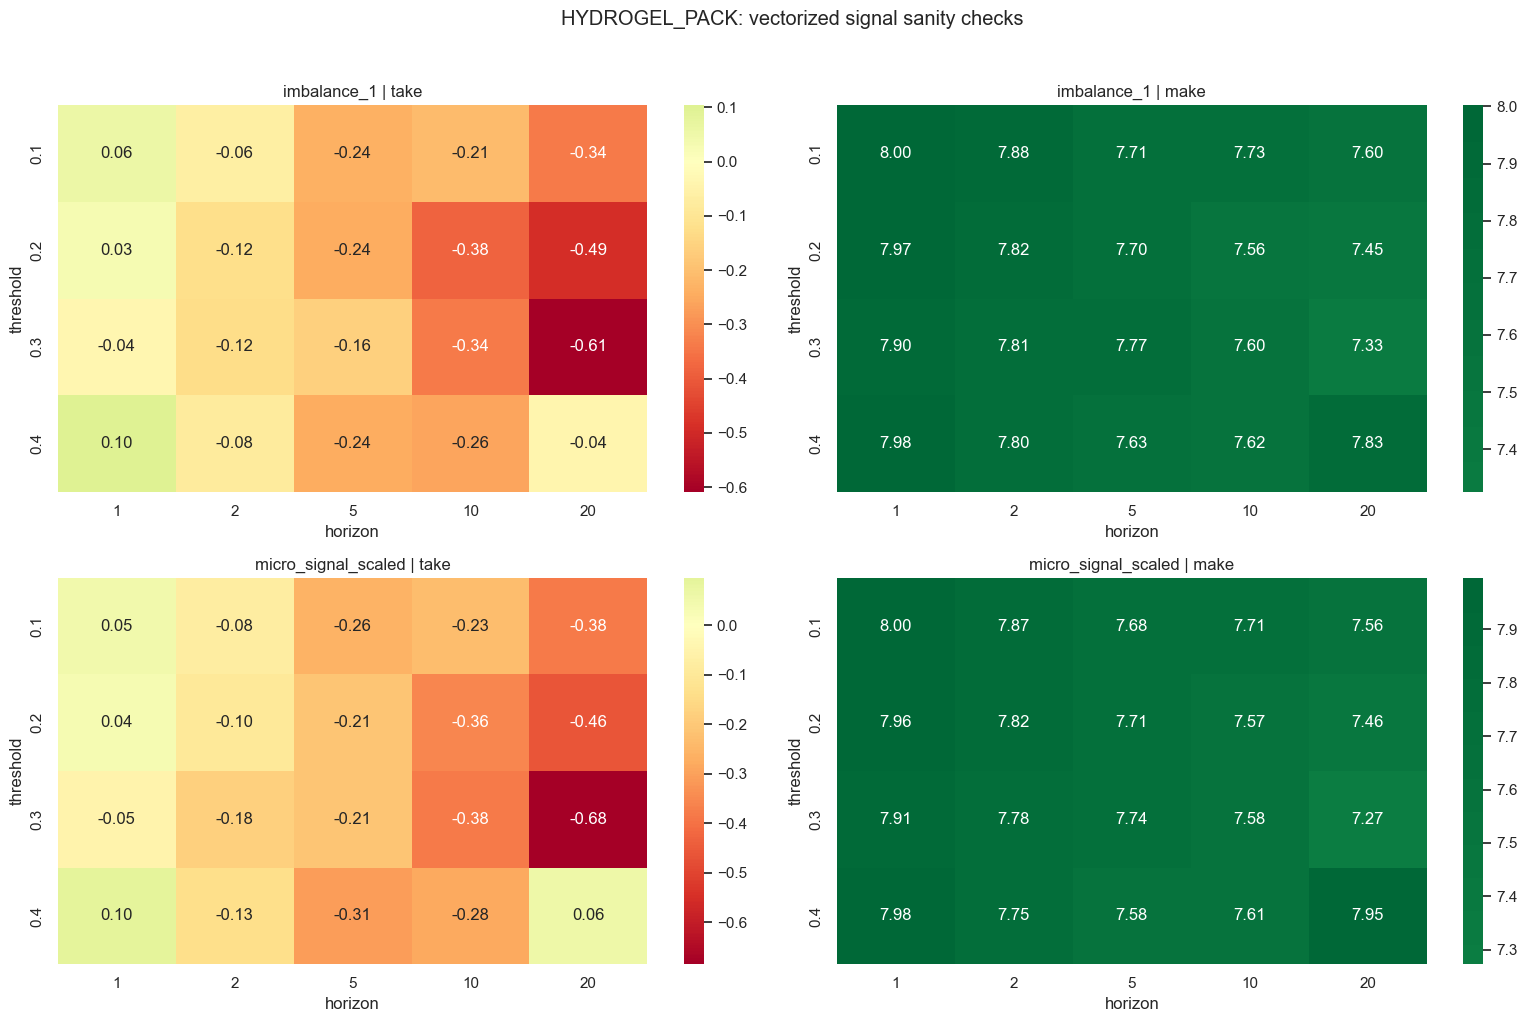

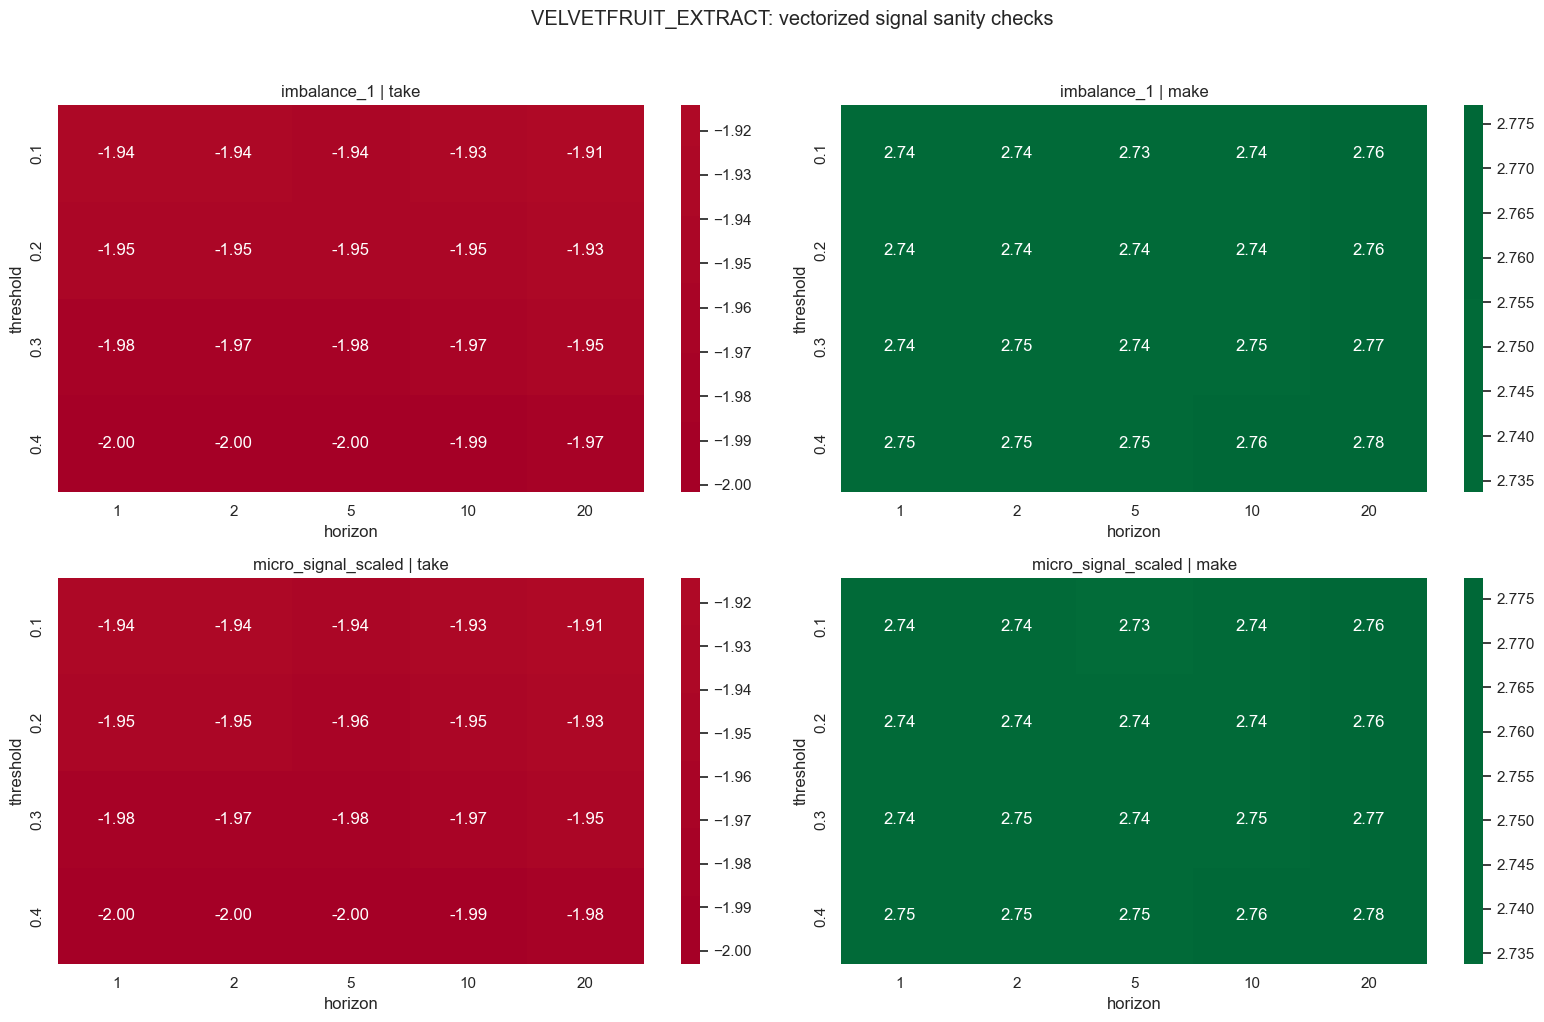

In [16]:

for product, res in underlying_strategy_results.items():
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    fig.suptitle(f'{product}: vectorized signal sanity checks', y=1.02)

    for ax, (signal, mode) in zip(
        axes.ravel(),
        [('imbalance_1', 'take'), ('imbalance_1', 'make'), ('micro_signal_scaled', 'take'), ('micro_signal_scaled', 'make')],
    ):
        tmp = res[(res['signal'] == signal) & (res['mode'] == mode)].pivot(index='threshold', columns='horizon', values='mean_pnl')
        sns.heatmap(tmp, annot=True, fmt='.2f', cmap='RdYlGn', center=0, ax=ax)
        ax.set_title(f'{signal} | {mode}')

    plt.tight_layout()
    plt.show()



## Voucher Threshold Tests in Price Space

Now we test whether option mispricings are tradable in price space.

For each active strike and fair-value anchor we:
- trigger when the option price residual is large relative to its own residual standard deviation,
- buy underpriced options at the ask and short overpriced options at the bid,
- mark the option to the future mid after a fixed holding horizon,
- estimate a simple static delta-hedge cost using the underlying spread and entry/exit deltas.

This is still a sanity check rather than a final execution model, but it is much closer to the real question: does the edge survive once hedging friction is acknowledged?


In [17]:

for label in ['global', 'local', 'rolling_strike']:
    iv_col = f'fair_iv_{label}'
    vouchers[f'delta_{label}'] = [
        norm_cdf((math.log(spot / strike) + 0.5 * sigma * sigma * (tte / 365.0)) / (sigma * math.sqrt(tte / 365.0)))
        if np.isfinite(sigma) and sigma > 0 and spot > 0 and strike > 0 and tte > 0 else np.nan
        for spot, strike, tte, sigma in zip(
            vouchers['underlying_mid'],
            vouchers['strike'],
            vouchers['tte_days'],
            vouchers[iv_col],
        )
    ]

VOUCHER_THRESHOLDS = [0.5, 1.0, 1.5, 2.0]
VOUCHER_HORIZONS = [1, 2, 5, 10, 20]
ACTIVE_VOUCHERS = [p for p in ACTIVE_VOUCHERS if p in vouchers['product'].unique()]


def evaluate_voucher_residual_strategy(vdf: pd.DataFrame, resid_col: str, delta_col: str, thresholds: list[float], horizons: list[int]) -> pd.DataFrame:
    rows = []
    resid_std = vdf[resid_col].std()
    if not np.isfinite(resid_std) or resid_std == 0:
        return pd.DataFrame()

    underlying_half_spread = (vdf['underlying_spread'].abs() / 2).replace(0, np.nan)

    for thr_mult in thresholds:
        thr = thr_mult * resid_std
        long_mask = vdf[resid_col] <= -thr
        short_mask = vdf[resid_col] >= thr

        for h in horizons:
            future_mid = vdf['mid_price'].shift(-h)
            future_delta = vdf[delta_col].shift(-h)

            gross_long = future_mid - vdf['ask_price_1']
            gross_short = vdf['bid_price_1'] - future_mid

            # Static two-point hedge-cost estimate: hedge at entry, unwind at exit.
            hedge_cost = underlying_half_spread * (vdf[delta_col].abs() + future_delta.abs())
            net_long = gross_long - hedge_cost
            net_short = gross_short - hedge_cost

            gross = pd.concat([gross_long[long_mask], gross_short[short_mask]])
            net = pd.concat([net_long[long_mask], net_short[short_mask]])
            hedge = pd.concat([hedge_cost[long_mask], hedge_cost[short_mask]])

            rows.append({
                'threshold_mult': thr_mult,
                'horizon': h,
                'count_long': int(long_mask.sum()),
                'count_short': int(short_mask.sum()),
                'count_total': int(long_mask.sum() + short_mask.sum()),
                'gross_mean_pnl': gross.mean(),
                'net_mean_pnl_after_static_hedge': net.mean(),
                'hedge_cost_mean': hedge.mean(),
                'gross_win_rate': (gross > 0).mean(),
                'net_win_rate': (net > 0).mean(),
                'avg_abs_delta_entry': pd.concat([vdf.loc[long_mask, delta_col].abs(), vdf.loc[short_mask, delta_col].abs()]).mean(),
            })
    return pd.DataFrame(rows)


vouchers['underlying_spread'] = (
    prices[prices['product'] == 'VELVETFRUIT_EXTRACT'][['day', 'timestamp', 'ask_price_1', 'bid_price_1']]
    .assign(underlying_spread=lambda x: x['ask_price_1'] - x['bid_price_1'])['underlying_spread']
)


In [18]:

# Rebuild underlying spread cleanly via merge to avoid alignment mistakes.
underlying_spread_df = (
    prices[prices['product'] == 'VELVETFRUIT_EXTRACT'][['day', 'timestamp', 'ask_price_1', 'bid_price_1']]
    .copy()
)
underlying_spread_df['underlying_spread'] = underlying_spread_df['ask_price_1'] - underlying_spread_df['bid_price_1']
vouchers = vouchers.drop(columns=['underlying_spread'], errors='ignore').merge(
    underlying_spread_df[['day', 'timestamp', 'underlying_spread']], on=['day', 'timestamp'], how='left'
)

voucher_threshold_results = []
for anchor in ['global', 'local', 'rolling_strike']:
    resid_col = f'price_resid_{anchor}'
    delta_col = f'delta_{anchor}'
    for product in ACTIVE_VOUCHERS:
        vdf = vouchers[vouchers['product'] == product].sort_values('global_timestamp').copy()
        res = evaluate_voucher_residual_strategy(vdf, resid_col, delta_col, VOUCHER_THRESHOLDS, VOUCHER_HORIZONS)
        if len(res):
            res['product'] = product
            res['anchor'] = anchor
            voucher_threshold_results.append(res)

voucher_threshold_results = pd.concat(voucher_threshold_results, ignore_index=True)
display(voucher_threshold_results.round(4))


,threshold_mult,horizon,count_long,count_short,count_total,gross_mean_pnl,net_mean_pnl_after_static_hedge,hedge_cost_mean,gross_win_rate,net_win_rate,avg_abs_delta_entry,product,anchor
0,0.5,1,29264,266,29530,-10.3122,-15.2985,4.9863,0.0085,0.0002,0.9897,VEV_4000,global
1,0.5,2,29264,266,29530,-10.3129,-15.2993,4.9863,0.0082,0.0002,0.9897,VEV_4000,global
2,0.5,5,29264,266,29530,-10.3071,-15.2935,4.9863,0.0086,0.0003,0.9897,VEV_4000,global
3,0.5,10,29264,266,29530,-10.3025,-15.2888,4.9863,0.0088,0.0012,0.9897,VEV_4000,global
4,0.5,20,29264,266,29530,-10.2855,-15.2719,4.9864,0.0168,0.0027,0.9897,VEV_4000,global
...,...,...,...,...,...,...,...,...,...,...,...,...,...
355,2.0,1,441,321,762,-0.5000,-0.5195,0.0195,0.0000,0.0000,0.0039,VEV_6500,rolling_strike
356,2.0,2,441,321,762,-0.5000,-0.5195,0.0195,0.0000,0.0000,0.0039,VEV_6500,rolling_strike
357,2.0,5,441,321,762,-0.5000,-0.5195,0.0195,0.0000,0.0000,0.0039,VEV_6500,rolling_strike
358,2.0,10,441,321,762,-0.5000,-0.5195,0.0195,0.0000,0.0000,0.0039,VEV_6500,rolling_strike


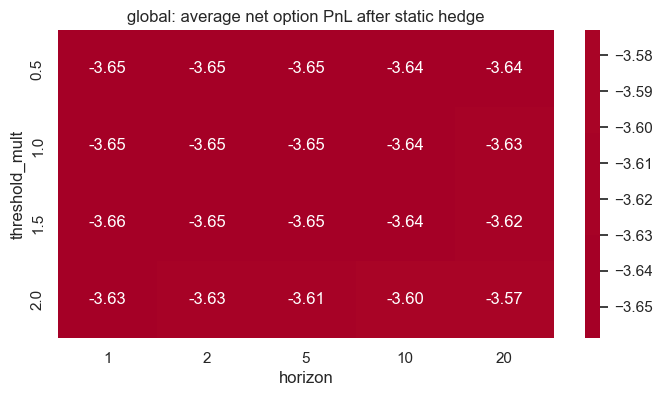

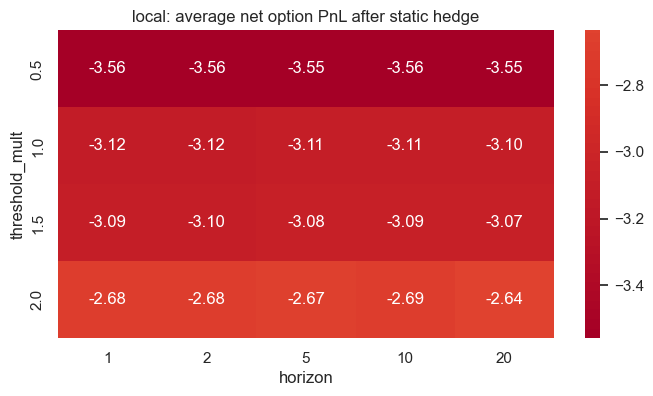

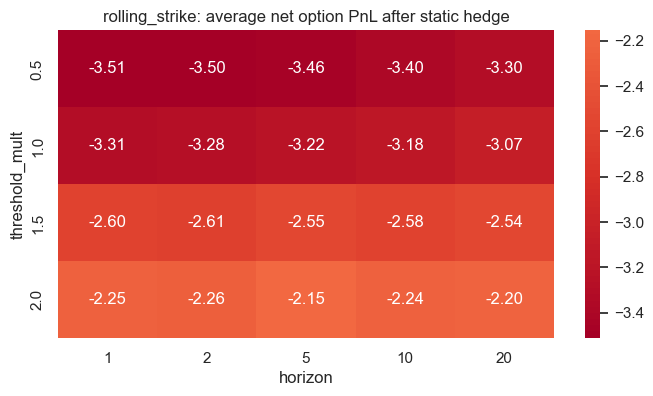

In [19]:

anchor_heatmap_metric = 'net_mean_pnl_after_static_hedge'

for anchor in ['global', 'local', 'rolling_strike']:
    tmp = (
        voucher_threshold_results[voucher_threshold_results['anchor'] == anchor]
        .groupby(['threshold_mult', 'horizon'])[anchor_heatmap_metric]
        .mean()
        .unstack()
    )
    plt.figure(figsize=(8, 4))
    sns.heatmap(tmp, annot=True, fmt='.2f', cmap='RdYlGn', center=0)
    plt.title(f'{anchor}: average net option PnL after static hedge')
    plt.show()


In [20]:

strike_level_summary = (
    voucher_threshold_results
    .groupby(['anchor', 'product'])[
        ['gross_mean_pnl', 'net_mean_pnl_after_static_hedge', 'hedge_cost_mean', 'avg_abs_delta_entry', 'count_total']
    ]
    .mean()
    .reset_index()
    .sort_values(['anchor', 'net_mean_pnl_after_static_hedge'], ascending=[True, False])
)

display(strike_level_summary.round(4))


,anchor,product,gross_mean_pnl,net_mean_pnl_after_static_hedge,hedge_cost_mean,avg_abs_delta_entry,count_total
4,global,VEV_6000,-0.5000,-0.5244,0.0244,0.0049,16065.00
5,global,VEV_6500,-0.5000,-0.5324,0.0324,0.0065,28966.00
3,global,VEV_5500,-0.4588,-0.8750,0.4162,0.0837,8723.75
2,global,VEV_5400,-0.6594,-1.6358,0.9764,0.1950,15622.75
1,global,VEV_5300,-1.0338,-2.9555,1.9217,0.3858,23319.75
0,global,VEV_4000,-10.2819,-15.2918,5.0099,0.9895,26687.75
11,local,VEV_6500,-0.5000,-0.5003,0.0003,0.0001,29944.25
10,local,VEV_6000,-0.5000,-0.5014,0.0014,0.0003,29996.50
9,local,VEV_5500,-0.5609,-0.9708,0.4100,0.0832,18395.25
8,local,VEV_5400,-0.6869,-1.6788,0.9920,0.1962,26154.50



## What To Look For In The New Output

Questions these sections should answer:
- Do imbalance and microprice signals survive aggressive entry, or only optimistic passive entry?
- Which underlyings, if any, are worth standalone trading rather than only supporting the vouchers?
- Which voucher anchor produces the best gross price-space signals?
- Does static delta hedging destroy the residual edge, or does some of it survive?
- Which strikes still look attractive after accounting for hedge cost?



## Voucher Passive-Entry Sanity Check

The aggressive voucher tests above answer whether crossing the spread is justified by residual mean reversion.
If those results are poor, the next question is whether the residual can still support a maker-style strategy.

Here we rerun the same threshold logic under an optimistic passive-entry assumption:
- buy underpriced options at the current best bid,
- sell overpriced options at the current best ask,
- mark to future mid,
- and compare gross PnL with and without the same static hedge-cost estimate.


In [21]:


def evaluate_voucher_passive_strategy(vdf: pd.DataFrame, resid_col: str, delta_col: str, thresholds: list[float], horizons: list[int]) -> pd.DataFrame:
    rows = []
    resid_std = vdf[resid_col].std()
    if not np.isfinite(resid_std) or resid_std == 0:
        return pd.DataFrame()

    underlying_half_spread = (vdf['underlying_spread'].abs() / 2).replace(0, np.nan)

    for thr_mult in thresholds:
        thr = thr_mult * resid_std
        long_mask = vdf[resid_col] <= -thr
        short_mask = vdf[resid_col] >= thr

        for h in horizons:
            future_mid = vdf['mid_price'].shift(-h)
            future_delta = vdf[delta_col].shift(-h)

            gross_long = future_mid - vdf['bid_price_1']
            gross_short = vdf['ask_price_1'] - future_mid

            hedge_cost = underlying_half_spread * (vdf[delta_col].abs() + future_delta.abs())
            net_long = gross_long - hedge_cost
            net_short = gross_short - hedge_cost

            gross = pd.concat([gross_long[long_mask], gross_short[short_mask]])
            net = pd.concat([net_long[long_mask], net_short[short_mask]])
            hedge = pd.concat([hedge_cost[long_mask], hedge_cost[short_mask]])

            rows.append({
                'threshold_mult': thr_mult,
                'horizon': h,
                'count_long': int(long_mask.sum()),
                'count_short': int(short_mask.sum()),
                'count_total': int(long_mask.sum() + short_mask.sum()),
                'gross_mean_pnl': gross.mean(),
                'net_mean_pnl_after_static_hedge': net.mean(),
                'hedge_cost_mean': hedge.mean(),
                'gross_win_rate': (gross > 0).mean(),
                'net_win_rate': (net > 0).mean(),
            })
    return pd.DataFrame(rows)


voucher_passive_results = []
for anchor in ['global', 'local', 'rolling_strike']:
    resid_col = f'price_resid_{anchor}'
    delta_col = f'delta_{anchor}'
    for product in ACTIVE_VOUCHERS:
        vdf = vouchers[vouchers['product'] == product].sort_values('global_timestamp').copy()
        res = evaluate_voucher_passive_strategy(vdf, resid_col, delta_col, VOUCHER_THRESHOLDS, VOUCHER_HORIZONS)
        if len(res):
            res['product'] = product
            res['anchor'] = anchor
            voucher_passive_results.append(res)

voucher_passive_results = pd.concat(voucher_passive_results, ignore_index=True)
display(voucher_passive_results.round(4))


,threshold_mult,horizon,count_long,count_short,count_total,gross_mean_pnl,net_mean_pnl_after_static_hedge,hedge_cost_mean,gross_win_rate,net_win_rate,product,anchor
0,0.5,1,29264,266,29530,10.4986,5.5123,4.9863,1.0000,0.9964,VEV_4000,global
1,0.5,2,29264,266,29530,10.4978,5.5115,4.9863,0.9999,0.9964,VEV_4000,global
2,0.5,5,29264,266,29530,10.5035,5.5172,4.9863,0.9998,0.9904,VEV_4000,global
3,0.5,10,29264,266,29530,10.5080,5.5217,4.9863,0.9990,0.9632,VEV_4000,global
4,0.5,20,29264,266,29530,10.5246,5.5382,4.9864,0.9924,0.9026,VEV_4000,global
...,...,...,...,...,...,...,...,...,...,...,...,...
355,2.0,1,441,321,762,0.5000,0.4805,0.0195,1.0000,1.0000,VEV_6500,rolling_strike
356,2.0,2,441,321,762,0.5000,0.4805,0.0195,1.0000,1.0000,VEV_6500,rolling_strike
357,2.0,5,441,321,762,0.5000,0.4805,0.0195,1.0000,1.0000,VEV_6500,rolling_strike
358,2.0,10,441,321,762,0.5000,0.4805,0.0195,1.0000,1.0000,VEV_6500,rolling_strike


In [22]:

comparison_rows = []
for anchor in ['global', 'local', 'rolling_strike']:
    take_tmp = (
        voucher_threshold_results[voucher_threshold_results['anchor'] == anchor]
        .groupby(['threshold_mult', 'horizon'])[['gross_mean_pnl', 'net_mean_pnl_after_static_hedge']]
        .mean()
        .reset_index()
        .rename(columns={
            'gross_mean_pnl': 'take_gross',
            'net_mean_pnl_after_static_hedge': 'take_net'
        })
    )
    make_tmp = (
        voucher_passive_results[voucher_passive_results['anchor'] == anchor]
        .groupby(['threshold_mult', 'horizon'])[['gross_mean_pnl', 'net_mean_pnl_after_static_hedge']]
        .mean()
        .reset_index()
        .rename(columns={
            'gross_mean_pnl': 'passive_gross',
            'net_mean_pnl_after_static_hedge': 'passive_net'
        })
    )
    merged = take_tmp.merge(make_tmp, on=['threshold_mult', 'horizon'], how='inner')
    merged['anchor'] = anchor
    comparison_rows.append(merged)

voucher_take_make_compare = pd.concat(comparison_rows, ignore_index=True)
display(voucher_take_make_compare.round(4))


,threshold_mult,horizon,take_gross,take_net,passive_gross,passive_net,anchor
0,0.5,1,-2.2645,-3.6543,2.3061,0.9164,global
1,0.5,2,-2.2631,-3.6529,2.3075,0.9177,global
2,0.5,5,-2.2586,-3.6484,2.3120,0.9222,global
3,0.5,10,-2.2546,-3.6443,2.3160,0.9262,global
4,0.5,20,-2.2465,-3.6363,2.3239,0.9342,global
5,1.0,1,-2.2600,-3.6532,2.3069,0.9137,global
6,1.0,2,-2.2578,-3.6509,2.3091,0.9159,global
7,1.0,5,-2.2520,-3.6452,2.3148,0.9216,global
8,1.0,10,-2.2467,-3.6398,2.3201,0.9269,global
9,1.0,20,-2.2363,-3.6294,2.3304,0.9372,global


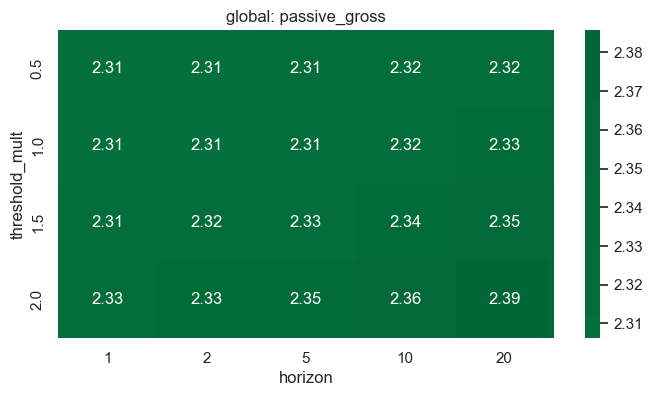

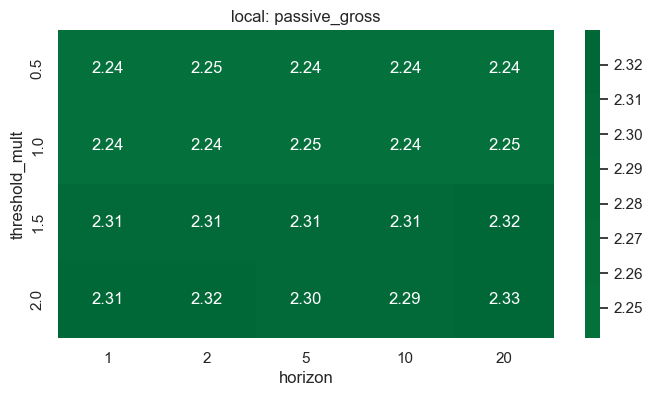

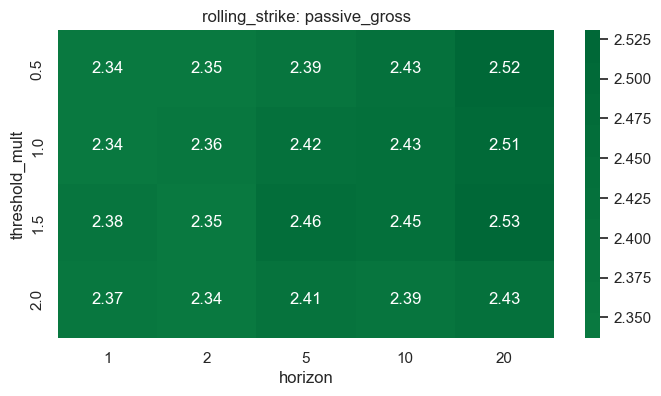

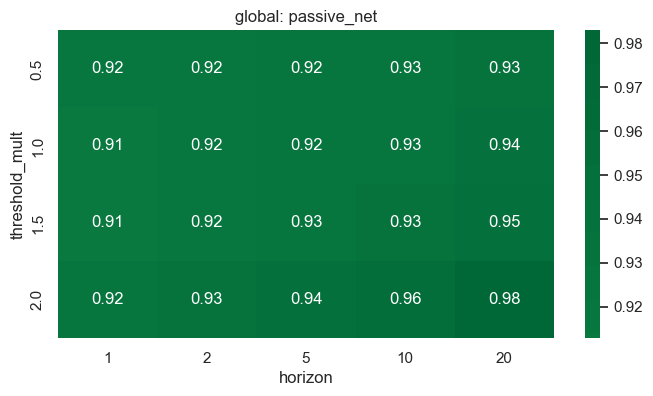

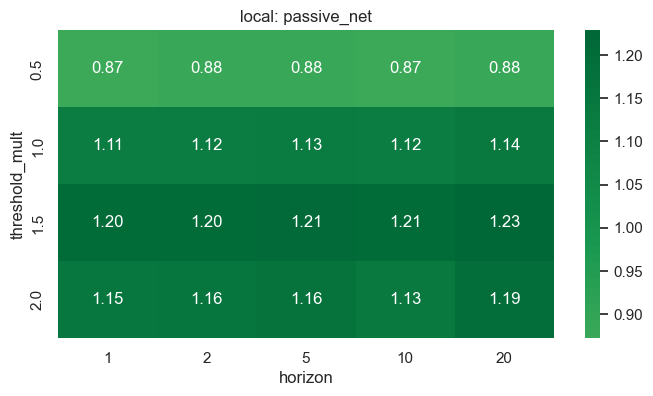

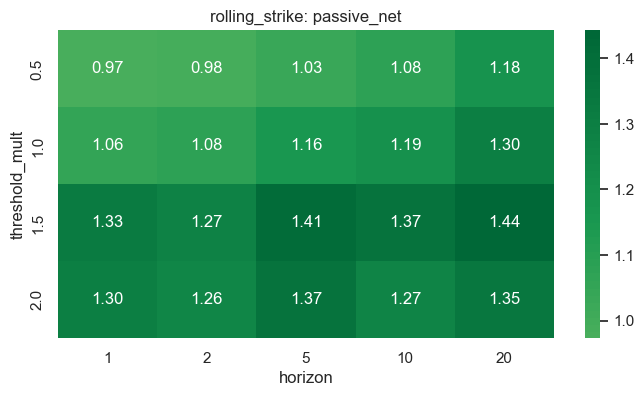

In [23]:

for metric in ['passive_gross', 'passive_net']:
    for anchor in ['global', 'local', 'rolling_strike']:
        tmp = (
            voucher_take_make_compare[voucher_take_make_compare['anchor'] == anchor]
            .pivot(index='threshold_mult', columns='horizon', values=metric)
        )
        plt.figure(figsize=(8, 4))
        sns.heatmap(tmp, annot=True, fmt='.2f', cmap='RdYlGn', center=0)
        plt.title(f'{anchor}: {metric}')
        plt.show()



### Interpretation Goal

If passive voucher entry is materially better than aggressive entry, that points toward:
- a quote-around-fair implementation,
- possibly with asymmetric thresholds by strike,
- and a much stronger need to estimate fill quality before coding the final trader.

If passive entry is still weak after this optimistic assumption, then we should shift more attention to:
- cross-strike relative value,
- selective strike activation,
- or reducing reliance on direct voucher trading.



## Cross-Strike Relative-Value Tests

Single-option fair-value residuals are only one way to look at the chain.
This section tests whether adjacent-strike spreads are cleaner.

For each adjacent active pair we compare:
- observed vertical spread,
- fair vertical spread under the chosen anchor,
- residual mean reversion of that spread,
- and a simple optimistic passive-entry spread trade.

This matters because vertical spreads carry much less net delta than outright options, so they may survive hedge friction better.


In [24]:

ACTIVE_VOUCHERS_SORTED = sorted(ACTIVE_VOUCHERS, key=strike_from_symbol)
ACTIVE_PAIRS = list(zip(ACTIVE_VOUCHERS_SORTED[:-1], ACTIVE_VOUCHERS_SORTED[1:]))
print('Active adjacent pairs:', ACTIVE_PAIRS)


def build_vertical_spread_frame(voucher_df: pd.DataFrame, lower_product: str, upper_product: str, anchor: str) -> pd.DataFrame:
    lower = voucher_df[voucher_df['product'] == lower_product][[
        'day', 'timestamp', 'global_timestamp', 'mid_price', 'bid_price_1', 'ask_price_1',
        f'fair_price_{anchor}', f'delta_{anchor}', 'underlying_spread'
    ]].copy()
    upper = voucher_df[voucher_df['product'] == upper_product][[
        'day', 'timestamp', 'global_timestamp', 'mid_price', 'bid_price_1', 'ask_price_1',
        f'fair_price_{anchor}', f'delta_{anchor}'
    ]].copy()

    lower = lower.rename(columns={
        'mid_price': 'mid_lower',
        'bid_price_1': 'bid_lower',
        'ask_price_1': 'ask_lower',
        f'fair_price_{anchor}': 'fair_lower',
        f'delta_{anchor}': 'delta_lower',
    })
    upper = upper.rename(columns={
        'mid_price': 'mid_upper',
        'bid_price_1': 'bid_upper',
        'ask_price_1': 'ask_upper',
        f'fair_price_{anchor}': 'fair_upper',
        f'delta_{anchor}': 'delta_upper',
    })

    spread = lower.merge(upper, on=['day', 'timestamp', 'global_timestamp'], how='inner')
    spread['obs_spread'] = spread['mid_lower'] - spread['mid_upper']
    spread['fair_spread'] = spread['fair_lower'] - spread['fair_upper']
    spread['spread_resid'] = spread['obs_spread'] - spread['fair_spread']
    spread['net_delta'] = spread['delta_lower'] - spread['delta_upper']
    return spread


def evaluate_vertical_spread_passive(spread_df: pd.DataFrame, thresholds: list[float], horizons: list[int]) -> pd.DataFrame:
    rows = []
    resid_std = spread_df['spread_resid'].std()
    if not np.isfinite(resid_std) or resid_std == 0:
        return pd.DataFrame()

    hedge_half_spread = (spread_df['underlying_spread'].abs() / 2).replace(0, np.nan)

    for thr_mult in thresholds:
        thr = thr_mult * resid_std
        # Positive residual = lower strike too rich vs upper strike; short spread.
        short_spread = spread_df['spread_resid'] >= thr
        long_spread = spread_df['spread_resid'] <= -thr

        for h in horizons:
            future_spread = spread_df['obs_spread'].shift(-h)
            future_net_delta = spread_df['net_delta'].shift(-h)

            # optimistic passive entry at touch
            long_entry = spread_df['bid_lower'] - spread_df['ask_upper']
            short_entry = spread_df['ask_lower'] - spread_df['bid_upper']

            pnl_long = future_spread - long_entry
            pnl_short = short_entry - future_spread

            hedge_cost = hedge_half_spread * (spread_df['net_delta'].abs() + future_net_delta.abs())
            net_long = pnl_long - hedge_cost
            net_short = pnl_short - hedge_cost

            gross = pd.concat([pnl_long[long_spread], pnl_short[short_spread]])
            net = pd.concat([net_long[long_spread], net_short[short_spread]])

            rows.append({
                'threshold_mult': thr_mult,
                'horizon': h,
                'count_total': int(long_spread.sum() + short_spread.sum()),
                'gross_mean_pnl': gross.mean(),
                'net_mean_pnl_after_static_hedge': net.mean(),
                'gross_win_rate': (gross > 0).mean(),
                'net_win_rate': (net > 0).mean(),
                'avg_abs_net_delta': pd.concat([spread_df.loc[long_spread, 'net_delta'].abs(), spread_df.loc[short_spread, 'net_delta'].abs()]).mean(),
            })
    return pd.DataFrame(rows)


vertical_results = []
for anchor in ['local', 'rolling_strike']:
    for lower, upper in ACTIVE_PAIRS:
        spread_df = build_vertical_spread_frame(vouchers, lower, upper, anchor)
        res = evaluate_vertical_spread_passive(spread_df, VOUCHER_THRESHOLDS, VOUCHER_HORIZONS)
        if len(res):
            res['anchor'] = anchor
            res['lower'] = lower
            res['upper'] = upper
            vertical_results.append(res)

vertical_results = pd.concat(vertical_results, ignore_index=True)
display(vertical_results.round(4))


Active adjacent pairs: [('VEV_4000', 'VEV_5300'), ('VEV_5300', 'VEV_5400'), ('VEV_5400', 'VEV_5500'), ('VEV_5500', 'VEV_6000'), ('VEV_6000', 'VEV_6500')]


,threshold_mult,horizon,count_total,gross_mean_pnl,net_mean_pnl_after_static_hedge,gross_win_rate,net_win_rate,avg_abs_net_delta,anchor,lower,upper
0,0.5,1,25734,11.4646,8.4539,0.9994,0.9637,0.6097,local,VEV_4000,VEV_5300
1,0.5,2,25734,11.4685,8.4610,0.9991,0.9647,0.6097,local,VEV_4000,VEV_5300
2,0.5,5,25734,11.4731,8.4632,0.9983,0.9650,0.6097,local,VEV_4000,VEV_5300
3,0.5,10,25734,11.4842,8.4728,0.9976,0.9656,0.6097,local,VEV_4000,VEV_5300
4,0.5,20,25734,11.5091,8.5000,0.9965,0.9651,0.6097,local,VEV_4000,VEV_5300
...,...,...,...,...,...,...,...,...,...,...,...
195,2.0,1,1355,1.0000,0.9899,1.0000,1.0000,0.0020,rolling_strike,VEV_6000,VEV_6500
196,2.0,2,1355,1.0000,0.9899,1.0000,1.0000,0.0020,rolling_strike,VEV_6000,VEV_6500
197,2.0,5,1355,1.0000,0.9899,1.0000,1.0000,0.0020,rolling_strike,VEV_6000,VEV_6500
198,2.0,10,1355,1.0000,0.9899,1.0000,1.0000,0.0020,rolling_strike,VEV_6000,VEV_6500


In [25]:

vertical_summary = (
    vertical_results
    .groupby(['anchor', 'lower', 'upper'])[
        ['gross_mean_pnl', 'net_mean_pnl_after_static_hedge', 'avg_abs_net_delta', 'count_total']
    ]
    .mean()
    .reset_index()
    .sort_values(['anchor', 'net_mean_pnl_after_static_hedge'], ascending=[True, False])
)

display(vertical_summary.round(4))


,anchor,lower,upper,gross_mean_pnl,net_mean_pnl_after_static_hedge,avg_abs_net_delta,count_total
0,local,VEV_4000,VEV_5300,11.4323,8.4652,0.6103,17656.50
4,local,VEV_6000,VEV_6500,1.0000,0.9965,0.0008,3644.25
3,local,VEV_5500,VEV_6000,1.1169,0.7961,0.0779,5673.75
1,local,VEV_5300,VEV_5400,1.7429,0.7581,0.1966,26926.25
2,local,VEV_5400,VEV_5500,1.2702,0.6835,0.1173,26989.00
5,rolling_strike,VEV_4000,VEV_5300,11.4275,8.4383,0.6385,250.00
6,rolling_strike,VEV_5300,VEV_5400,2.0785,1.0833,0.2088,8229.50
7,rolling_strike,VEV_5400,VEV_5500,1.4838,0.9966,0.0990,8386.00
9,rolling_strike,VEV_6000,VEV_6500,1.0000,0.9906,0.0019,8326.25
8,rolling_strike,VEV_5500,VEV_6000,1.1838,0.8124,0.0757,8107.75



## Trade-at-Touch Fill Proxy

We do not know actual passive fill probabilities from the backtester alone, but we can at least measure how often the tape prints at the top of book.

For each product we compute a simple proxy:
- whether there was a trade at the best ask,
- whether there was a trade at the best bid,
- and how often that occurs overall.

This is not a true fill model. It is only a sanity check for whether quoting at touch is even plausible.


In [26]:

trade_touch_rows = []

for product in ['HYDROGEL_PACK', 'VELVETFRUIT_EXTRACT'] + ACTIVE_VOUCHERS:
    price_df = prices[prices['product'] == product][['day', 'timestamp', 'bid_price_1', 'ask_price_1']].copy()
    trade_df = trades[trades['symbol'] == product][['day', 'timestamp', 'price', 'quantity']].copy()

    if len(trade_df) == 0:
        continue

    merged = trade_df.merge(price_df, on=['day', 'timestamp'], how='left')
    merged['at_bid'] = np.isclose(merged['price'], merged['bid_price_1'])
    merged['at_ask'] = np.isclose(merged['price'], merged['ask_price_1'])

    per_ts = merged.groupby(['day', 'timestamp']).agg(
        any_at_bid=('at_bid', 'max'),
        any_at_ask=('at_ask', 'max'),
        trade_count=('price', 'size'),
    ).reset_index()

    trade_touch_rows.append({
        'product': product,
        'timestamps_with_trades': len(per_ts),
        'share_trade_timestamps_at_bid': per_ts['any_at_bid'].mean(),
        'share_trade_timestamps_at_ask': per_ts['any_at_ask'].mean(),
        'share_trade_timestamps_touch_either_side': (per_ts['any_at_bid'] | per_ts['any_at_ask']).mean(),
        'avg_trades_per_trade_timestamp': per_ts['trade_count'].mean(),
    })

trade_touch_summary = pd.DataFrame(trade_touch_rows).sort_values('share_trade_timestamps_touch_either_side', ascending=False)
display(trade_touch_summary.round(4))


,product,timestamps_with_trades,share_trade_timestamps_at_bid,share_trade_timestamps_at_ask,share_trade_timestamps_touch_either_side,avg_trades_per_trade_timestamp
0,HYDROGEL_PACK,1010,0.4812,0.5188,1.0000,1.0000
2,VEV_4000,464,0.5129,0.4871,1.0000,1.0000
4,VEV_5400,225,1.0000,0.0000,1.0000,1.0000
5,VEV_5500,267,1.0000,0.0000,1.0000,1.0000
6,VEV_6000,284,1.0000,0.0000,1.0000,1.0000
7,VEV_6500,284,1.0000,0.0000,1.0000,1.0000
1,VELVETFRUIT_EXTRACT,1363,0.4321,0.5686,0.9971,1.0066
3,VEV_5300,121,0.9835,0.0083,0.9917,1.0000



### Decision Use

If vertical spreads look cleaner than outright options, or if touch-trade activity is too weak for some products, the first trader should reflect that directly:
- fewer outright option quotes,
- more focus on the cleanest strikes or spreads,
- and lower confidence in optimistic passive-entry assumptions where the tape rarely trades at touch.



## Interim Findings

Current evidence from the targeted tests:

### Delta-1 Products
- Both `HYDROGEL_PACK` and `VELVETFRUIT_EXTRACT` show mild short-horizon return reversal, but not enough to justify a naive rolling-z-score strategy by itself.
- Top-of-book imbalance and microprice skew are materially more informative than rolling z-score for both products.
- `HYDROGEL_PACK` appears wider and noisier, but still exhibits useful imbalance signal.
- `VELVETFRUIT_EXTRACT` is tighter and likely more important as the pricing anchor for the voucher family than as a standalone directional product.

### Voucher Surface
- A pooled global quadratic smile is too coarse: its price residuals are larger and less balanced.
- A timestamp-local cross-sectional smile materially improves residual quality and produces stronger residual mean reversion.
- A rolling per-strike IV anchor minimizes residual size, but its residuals are more persistent; that makes it plausible as a slow anchor, but weaker as a pure short-horizon scalping signal.
- The current best hypothesis is that the first voucher strategy should be based on local cross-sectional relative value, potentially filtered or stabilized by rolling per-strike IV.

### Strike Selection
- Trade activity is highly uneven.
- The dead or near-dead strikes (`VEV_4500`, `VEV_5000`, `VEV_5100`, and probably `VEV_5200`) should not be assumed useful in the first implementation.
- The active initial universe is concentrated in `VEV_4000`, `VEV_5300`, `VEV_5400`, `VEV_5500`, `VEV_6000`, and `VEV_6500`.

### Working Hypothesis For Next Stage
- For the underlyings: test book-imbalance/microprice-based take-make logic before any more complex directional model.
- For vouchers: focus next on price-space residual trading, candidate thresholds by strike, and hedge-cost analysis.



## Updated Findings After Passive Voucher Tests

### Core directional conclusion
- Aggressive voucher taking against the current option spread is not supported by the current residual tests.
- Under every anchor tested, aggressive voucher entry is negative on average even before a static hedge-cost estimate is applied.
- Passive voucher entry is much more promising: buying underpriced options at the bid and selling overpriced options at the ask produces positive average gross PnL, and in several cases still positive average net PnL after a crude static hedge-cost estimate.

### Anchor conclusion
- `rolling_strike` and `local` are both more plausible than a static global smile for live trading.
- `local` gives the cleanest short-horizon residual-reversion picture.
- `rolling_strike` often produces the strongest optimistic passive-entry economics, suggesting it may be useful as a quoting anchor even if it is weaker as a pure mean-reversion signal.
- This points toward a blended implementation idea: local cross-sectional structure for direction, rolling per-strike IV for stability.

### Strike conclusion
The passive-entry tests suggest the first implementation should be selective.

Most attractive early candidates:
- `VEV_4000`: strongest passive-entry economics in the notebook so far, though less frequent and needing caution because of high delta.
- `VEV_6000` and `VEV_6500`: modest but consistently positive passive-entry results, likely tied to tight/pinned pricing and spread capture.
- `VEV_5500`: weaker than the above, but still a plausible candidate.

Mixed / less convincing so far:
- `VEV_5300`
- `VEV_5400`

Low-priority / likely ignore initially due to inactivity:
- `VEV_4500`
- `VEV_5000`
- `VEV_5100`
- probably `VEV_5200`

### Underlying conclusion
- The underlyings look more like market-making products with useful skew signals than simple aggressive directional products.
- The strong optimistic passive-entry results for `HYDROGEL_PACK` and `VELVETFRUIT_EXTRACT` should be read mainly as evidence that spread capture matters, not that fills are guaranteed.
- Imbalance and microprice skew remain the better candidates for quote skew / selective taking than rolling z-score reversion.

### Most likely strategy direction now
The current notebook evidence points toward:
1. passive or semi-passive trading on the underlyings, with imbalance/microprice skew;
2. voucher quoting around a dynamic fair anchor rather than pure aggressive scalping;
3. selective strike activation, not full-chain trading from day one;
4. careful treatment of hedging, because full mechanical hedging may erase too much of the edge.



## Next Targeted Sections

Planned additions after the broad pass:
- `HYDROGEL_PACK`: reversal horizon, book imbalance, and take/make sanity checks.
- `VELVETFRUIT_EXTRACT`: same tests, plus role as the voucher anchor.
- `VEV_*`: implied vol surface plots, moneyness buckets, rolling/local IV comparisons, and price-space mispricing tests.
- Hedging analysis: delta exposure, hedge-cost estimates, and unhedged risk bounds.
